In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi']      = 130
plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['font.size']       = 11

df = pd.read_csv('/content/drive/MyDrive/fraud_v2.csv')

print(f"Shape     : {df.shape}")
print(f"Fraud     : {df['is_fraud'].sum():,}  ({df['is_fraud'].mean()*100:.2f}%)")
print(f"Legit     : {(df['is_fraud']==0).sum():,}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape     : (400000, 88)
Fraud     : 42,331  (10.58%)
Legit     : 357,669

Columns:
['transaction_id', 'user_id', 'session_id', 'age', 'gender', 'city', 'state', 'employment_type', 'education_level', 'annual_income_inr', 'pan_verified', 'aadhaar_linked', 'cibil_score', 'crif_score', 'experian_score', 'equifax_score', 'bearo_score', 'card_network', 'card_type', 'card_bin', 'card_last4', 'card_expiry', 'issuer_bank', 'card_limit_inr', 'card_age_days', 'is_virtual_card', 'txn_amount', 'txn_currency', 'is_international_txn', 'txn_channel', 'upi_id', 'merchant_category', 'merchant_id', 'merchant_city', 'txn_city_matches_home', 'txn_hour', 'txn_day_of_week', 'txn_month', 'txn_weekend', 'is_split_txn', 'split_count', 'txn_count_last_1h', 'txn_count_last_24h', 'txn_count_last_7d', 'txn_count_last_30d', 'avg_txn_amount_7d', 'txn_vs_avg_ratio', 'failed_txn_count_24h', 'diff_merchants_24h', 'diff_cities_7d', 'max_single_txn_30d', 'amt_percentile_rank', 'device_os', 'device_brand', 'browser', 'bro

    merchant_category  total_txns  fraud_txns  fraud_rate_%  txn_share_%
         Luxury Goods        8173        1417         17.34         2.04
            Jewellery       15955        2231         13.98         3.99
          Electronics       27290        3511         12.87         6.82
      Crypto Exchange       11499        1417         12.32         2.87
      Pharmaceuticals       19437        2266         11.66         4.86
    Travel & Airlines       22984        2600         11.31         5.75
          Restaurants       27413        3048         11.12         6.85
              Grocery       38221        4202         10.99         9.56
           E-Commerce       60977        6407         10.51        15.24
        Utility Bills       26442        2765         10.46         6.61
Subscription Services       11056        1055          9.54         2.76
          Real Estate        7397         684          9.25         1.85
           Healthcare       11072         998      

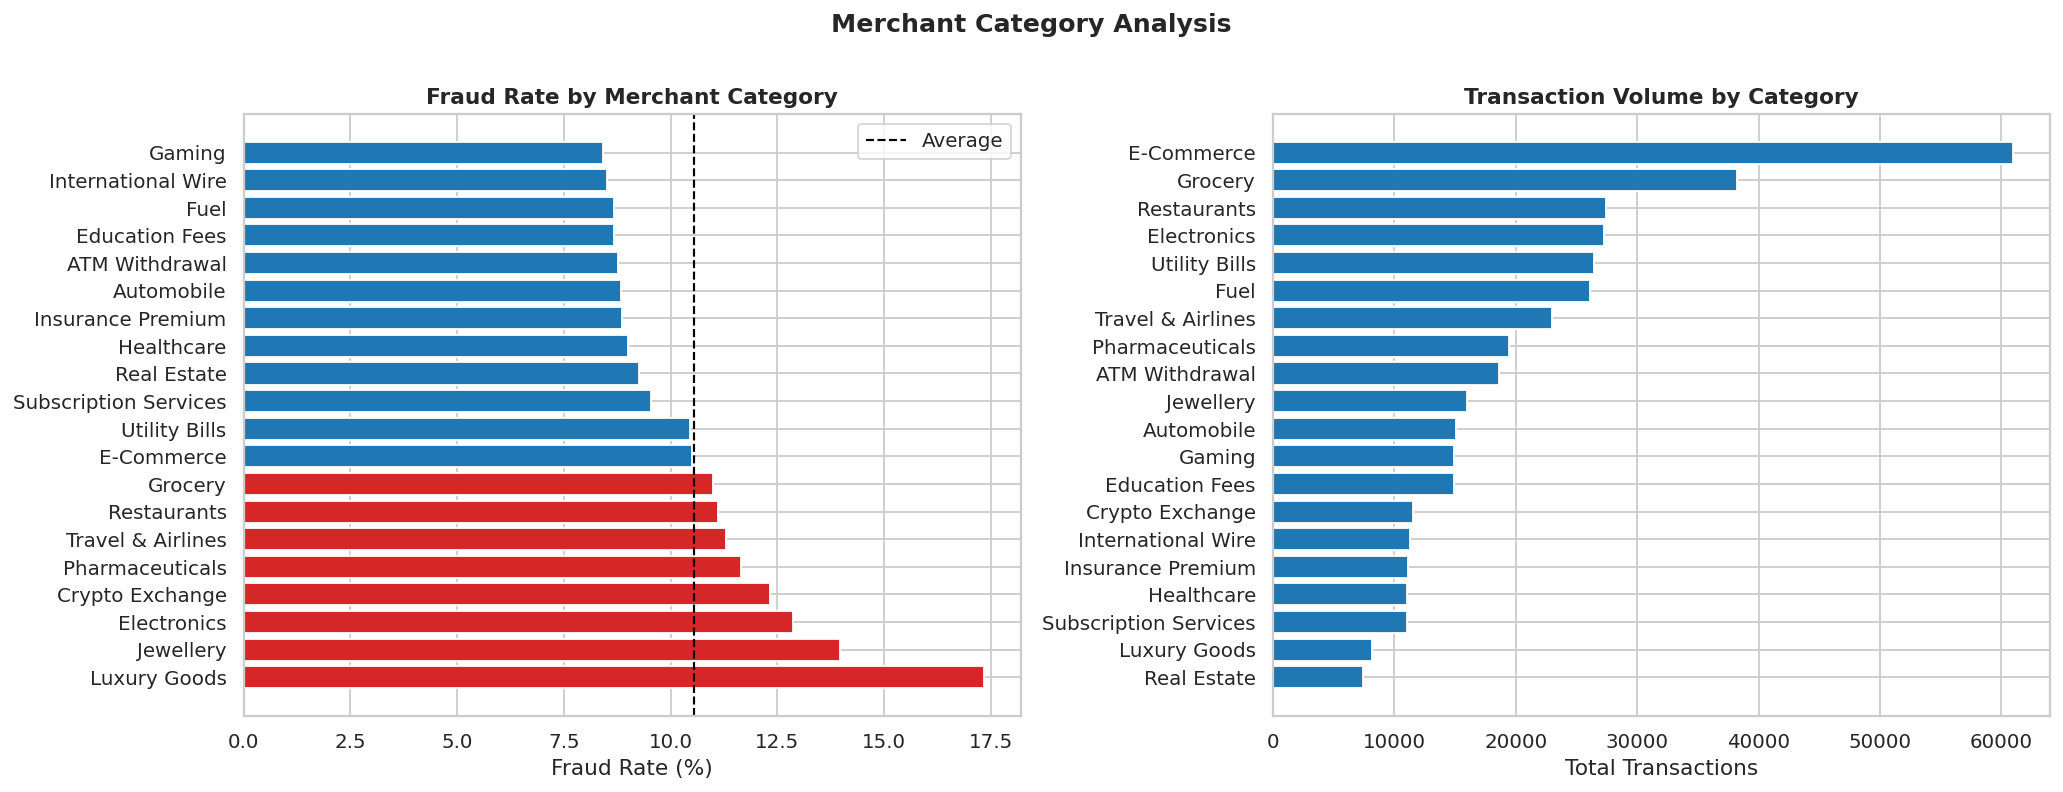

In [3]:
# Calculate fraud rate per merchant category
merchant_fraud = df.groupby('merchant_category').agg(
    total_txns  = ('is_fraud', 'count'),
    fraud_txns  = ('is_fraud', 'sum')
).reset_index()

merchant_fraud['fraud_rate_%'] = (merchant_fraud['fraud_txns'] /
                                   merchant_fraud['total_txns'] * 100).round(2)
merchant_fraud['txn_share_%']  = (merchant_fraud['total_txns'] /
                                   len(df) * 100).round(2)

merchant_fraud = merchant_fraud.sort_values('fraud_rate_%', ascending=False)

print(merchant_fraud.to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — fraud rate per category
axes[0].barh(merchant_fraud['merchant_category'],
             merchant_fraud['fraud_rate_%'],
             color=['#d62728' if x > merchant_fraud['fraud_rate_%'].mean()
                    else '#1f77b4' for x in merchant_fraud['fraud_rate_%']])
axes[0].axvline(merchant_fraud['fraud_rate_%'].mean(),
                color='black', linestyle='--', linewidth=1.2, label='Average')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Merchant Category', fontweight='bold')
axes[0].legend()

# Right — transaction volume per category
axes[1].barh(merchant_fraud.sort_values('total_txns')['merchant_category'],
             merchant_fraud.sort_values('total_txns')['total_txns'],
             color='#1f77b4')
axes[1].set_xlabel('Total Transactions')
axes[1].set_title('Transaction Volume by Category', fontweight='bold')

plt.suptitle('Merchant Category Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

E-Commerce has the highest transaction volume at 60,000+ transactions but sits below the fraud average. Meanwhile Luxury Goods has one of the smallest volumes at ~9,000 transactions but the highest fraud rate at 17.5% — nearly double the average. This means we should not just monitor high-volume categories but specifically set tighter controls on low-volume, high-value categories.


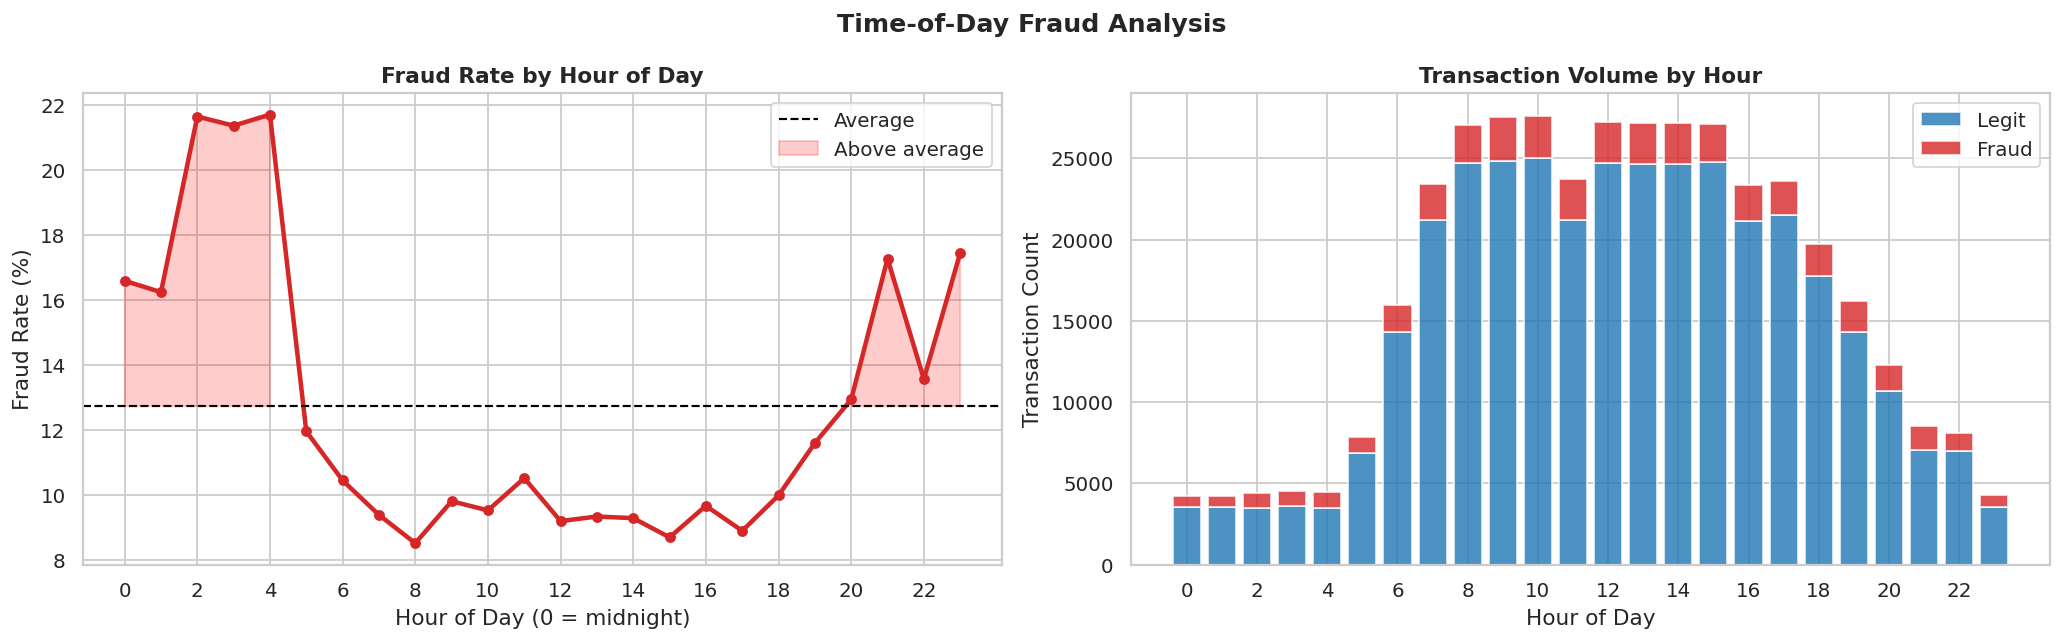

Top 5 highest fraud rate hours:
 txn_hour  fraud_rate_%  total  fraud
        4         21.71   4467    970
        2         21.65   4424    958
        3         21.37   4562    975
       23         17.45   4292    749
       21         17.28   8545   1477


In [4]:
# Fraud rate by hour
hourly = df.groupby('txn_hour').agg(
    total = ('is_fraud', 'count'),
    fraud = ('is_fraud', 'sum')
).reset_index()
hourly['fraud_rate_%'] = (hourly['fraud'] / hourly['total'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left — fraud rate by hour
axes[0].plot(hourly['txn_hour'], hourly['fraud_rate_%'],
             color='#d62728', linewidth=2.5, marker='o', markersize=5)
axes[0].axhline(hourly['fraud_rate_%'].mean(),
                color='black', linestyle='--', linewidth=1.2, label='Average')
axes[0].fill_between(hourly['txn_hour'], hourly['fraud_rate_%'],
                     hourly['fraud_rate_%'].mean(),
                     where=hourly['fraud_rate_%'] > hourly['fraud_rate_%'].mean(),
                     alpha=0.2, color='red', label='Above average')
axes[0].set_xlabel('Hour of Day (0 = midnight)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Right — transaction volume by hour split by fraud/legit
fraud_by_hour = df[df['is_fraud']==1].groupby('txn_hour').size()
legit_by_hour = df[df['is_fraud']==0].groupby('txn_hour').size()

axes[1].bar(hourly['txn_hour'], legit_by_hour.values,
            label='Legit', color='#1f77b4', alpha=0.8)
axes[1].bar(hourly['txn_hour'], fraud_by_hour.values,
            bottom=legit_by_hour.values,
            label='Fraud', color='#d62728', alpha=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Transaction Volume by Hour', fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.suptitle('Time-of-Day Fraud Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print peak fraud hours
print("Top 5 highest fraud rate hours:")
print(hourly.nlargest(5, 'fraud_rate_%')[['txn_hour','fraud_rate_%','total','fraud']].to_string(index=False))

Fraud doesn't follow transaction volume — it follows opportunity. Between 2–4 AM, transaction volume drops to its lowest point at ~4,400 per hour, yet fraud rate peaks at 21.7% — nearly double the daily average. This is when fraud detection systems are least monitored and victims are asleep. However the absolute fraud count is actually higher during business hours 9AM–3PM simply due to volume. This means a bank needs TWO different strategies — rate-based alerts at night, volume-based alerts during the day.

Also, a peak at hour 11 signals for the account takeover lunch pattern. Fraudsters who work business hours, taking over accounts during their lunch breaks.

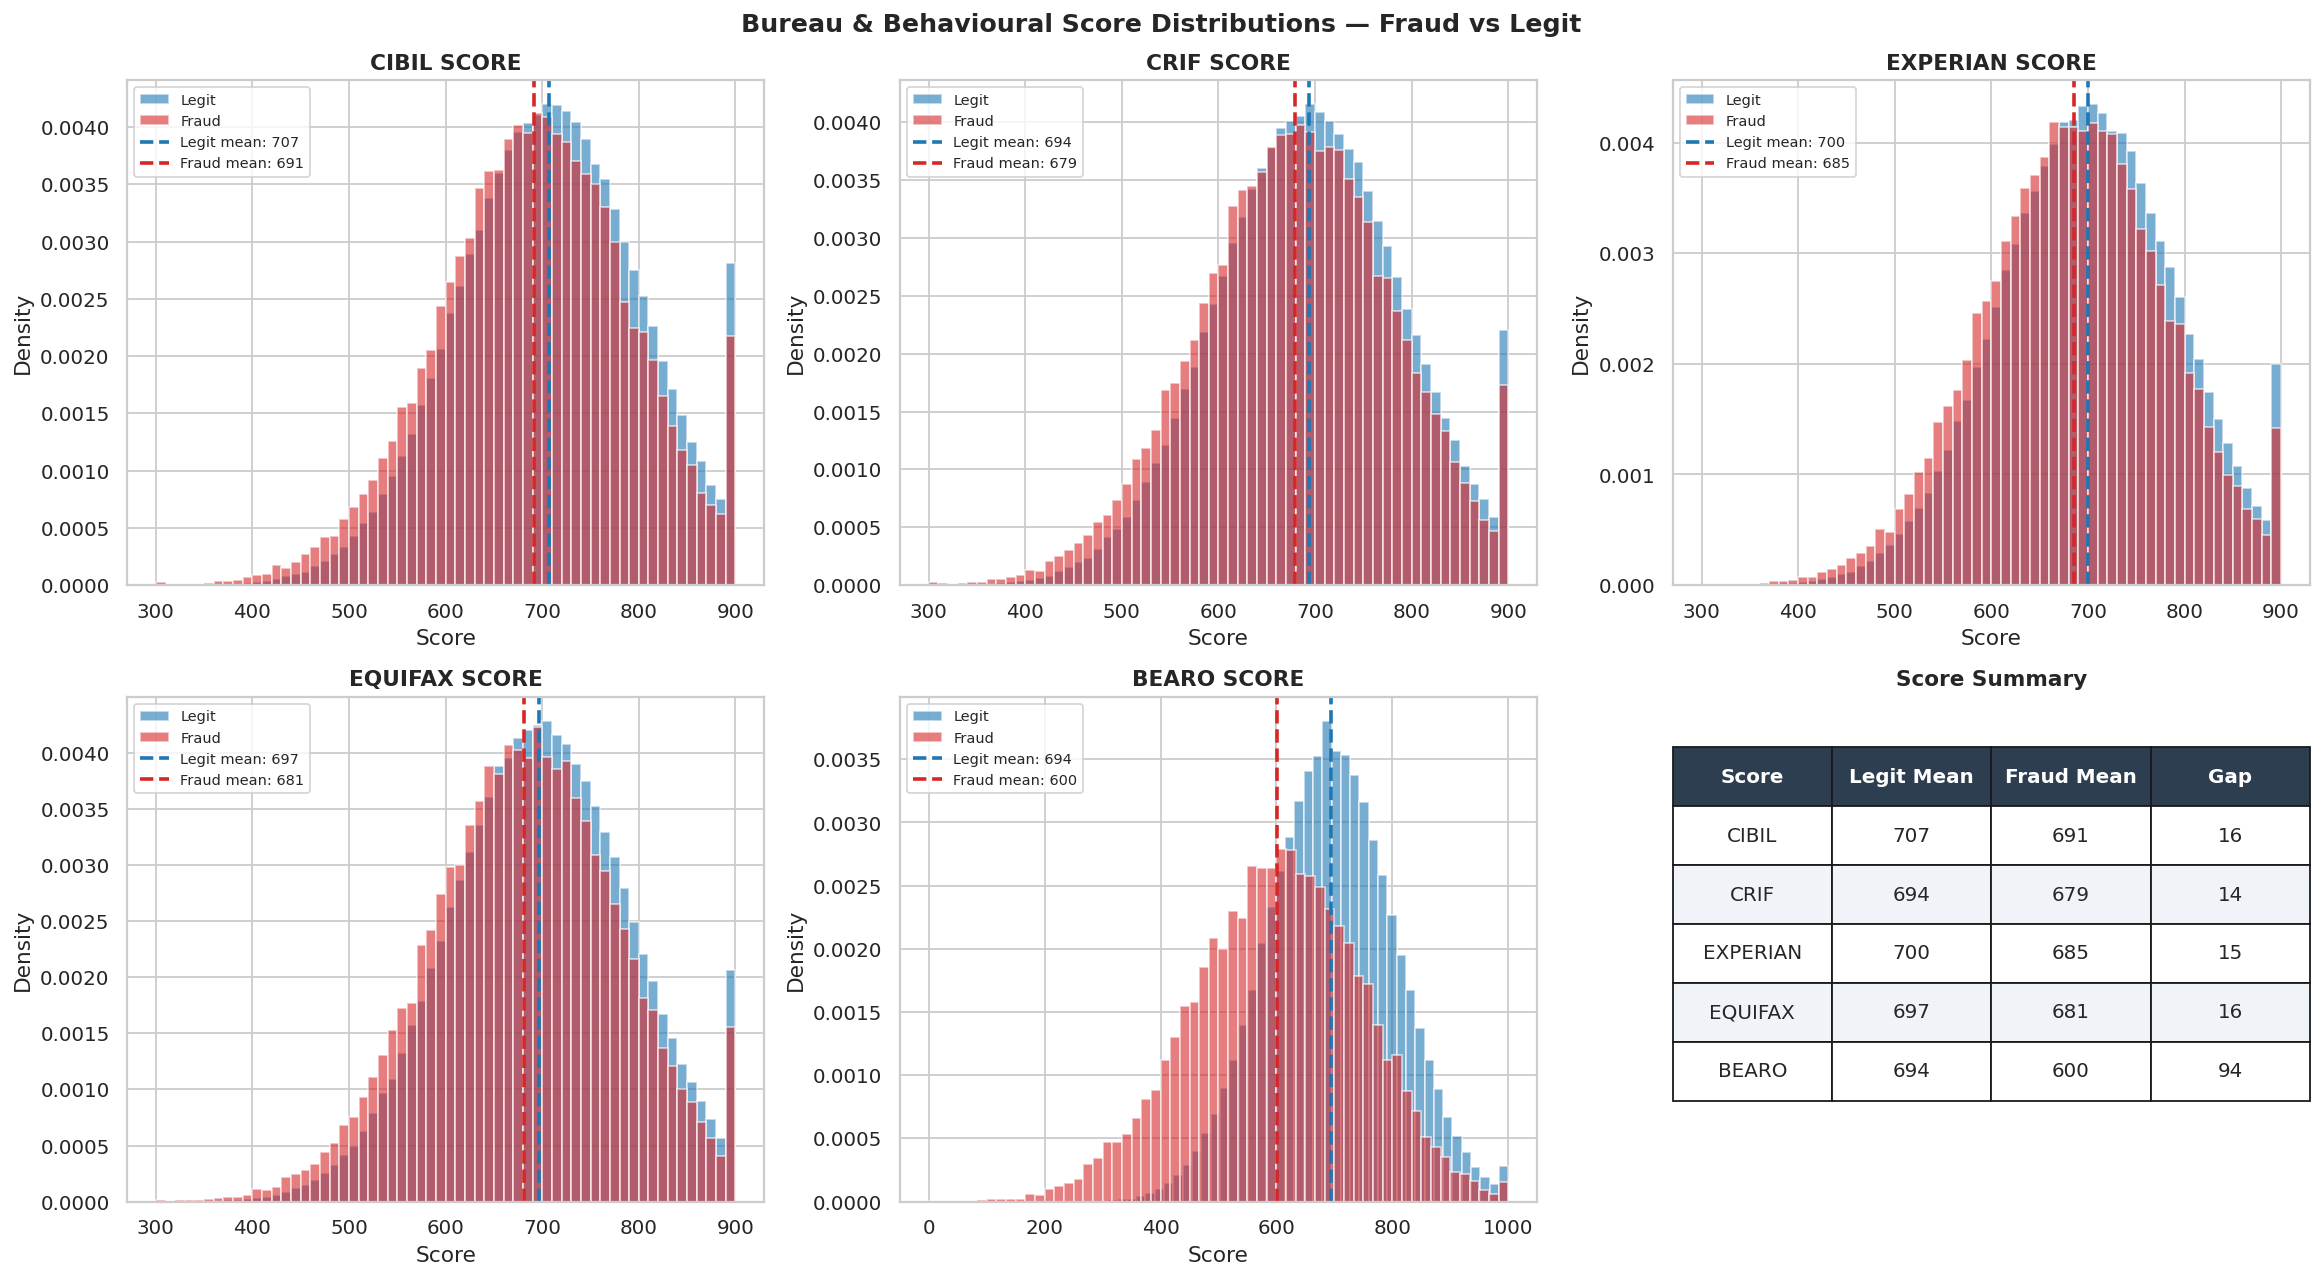


Score Comparison Summary:
Score                Legit Mean   Fraud Mean      Gap   Overlap?
-----------------------------------------------------------------
cibil_score               706.9        691.2     15.7 Yes - heavy
crif_score                693.7        679.3     14.4 Yes - heavy
experian_score            699.9        685.3     14.6 Yes - heavy
equifax_score             697.0        681.4     15.7 Yes - heavy
bearo_score               694.1        600.3     93.8   Moderate


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

score_cols = ['cibil_score','crif_score','experian_score',
              'equifax_score','bearo_score']

for idx, col in enumerate(score_cols):
    fraud_vals = df[df['is_fraud']==1][col]
    legit_vals = df[df['is_fraud']==0][col]

    axes[idx].hist(legit_vals, bins=60, alpha=0.6,
                   color='#1f77b4', label='Legit', density=True)
    axes[idx].hist(fraud_vals, bins=60, alpha=0.6,
                   color='#d62728', label='Fraud', density=True)

    # Mean lines
    axes[idx].axvline(legit_vals.mean(), color='#1f77b4',
                      linestyle='--', linewidth=2,
                      label=f'Legit mean: {legit_vals.mean():.0f}')
    axes[idx].axvline(fraud_vals.mean(), color='#d62728',
                      linestyle='--', linewidth=2,
                      label=f'Fraud mean: {fraud_vals.mean():.0f}')

    axes[idx].set_title(f'{col.upper().replace("_"," ")}', fontweight='bold')
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)

# Last subplot — mean comparison table
axes[5].axis('off')
score_summary = []
for col in score_cols:
    legit_mean = df[df['is_fraud']==0][col].mean()
    fraud_mean = df[df['is_fraud']==1][col].mean()
    gap        = legit_mean - fraud_mean
    score_summary.append([col.replace('_score','').upper(),
                          f'{legit_mean:.0f}',
                          f'{fraud_mean:.0f}',
                          f'{gap:.0f}'])

table = axes[5].table(
    cellText=score_summary,
    colLabels=['Score','Legit Mean','Fraud Mean','Gap'],
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.7]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
axes[5].set_title('Score Summary', fontweight='bold')

plt.suptitle('Bureau & Behavioural Score Distributions — Fraud vs Legit',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print("\nScore Comparison Summary:")
print(f"{'Score':<18} {'Legit Mean':>12} {'Fraud Mean':>12} {'Gap':>8} {'Overlap?':>10}")
print("-" * 65)
for col in score_cols:
    lm = df[df['is_fraud']==0][col].mean()
    fm = df[df['is_fraud']==1][col].mean()
    print(f"{col:<18} {lm:>12.1f} {fm:>12.1f} {lm-fm:>8.1f} {'Yes - heavy' if abs(lm-fm) < 60 else 'Moderate':>10}")

This is why rule-based fraud systems fail. Banks traditionally rely on bureau scores to assess risk — but our analysis shows the mean CIBIL score gap between fraudulent and legitimate transactions is only 16 points, with near-complete distribution overlap. A fraudster at 691 is statistically indistinguishable from a legitimate customer at 691. This proves that no single score can detect fraud — you need a model that combines bureau scores with behavioural signals, device intelligence, and velocity patterns simultaneously. This is exactly what XGBoost does.

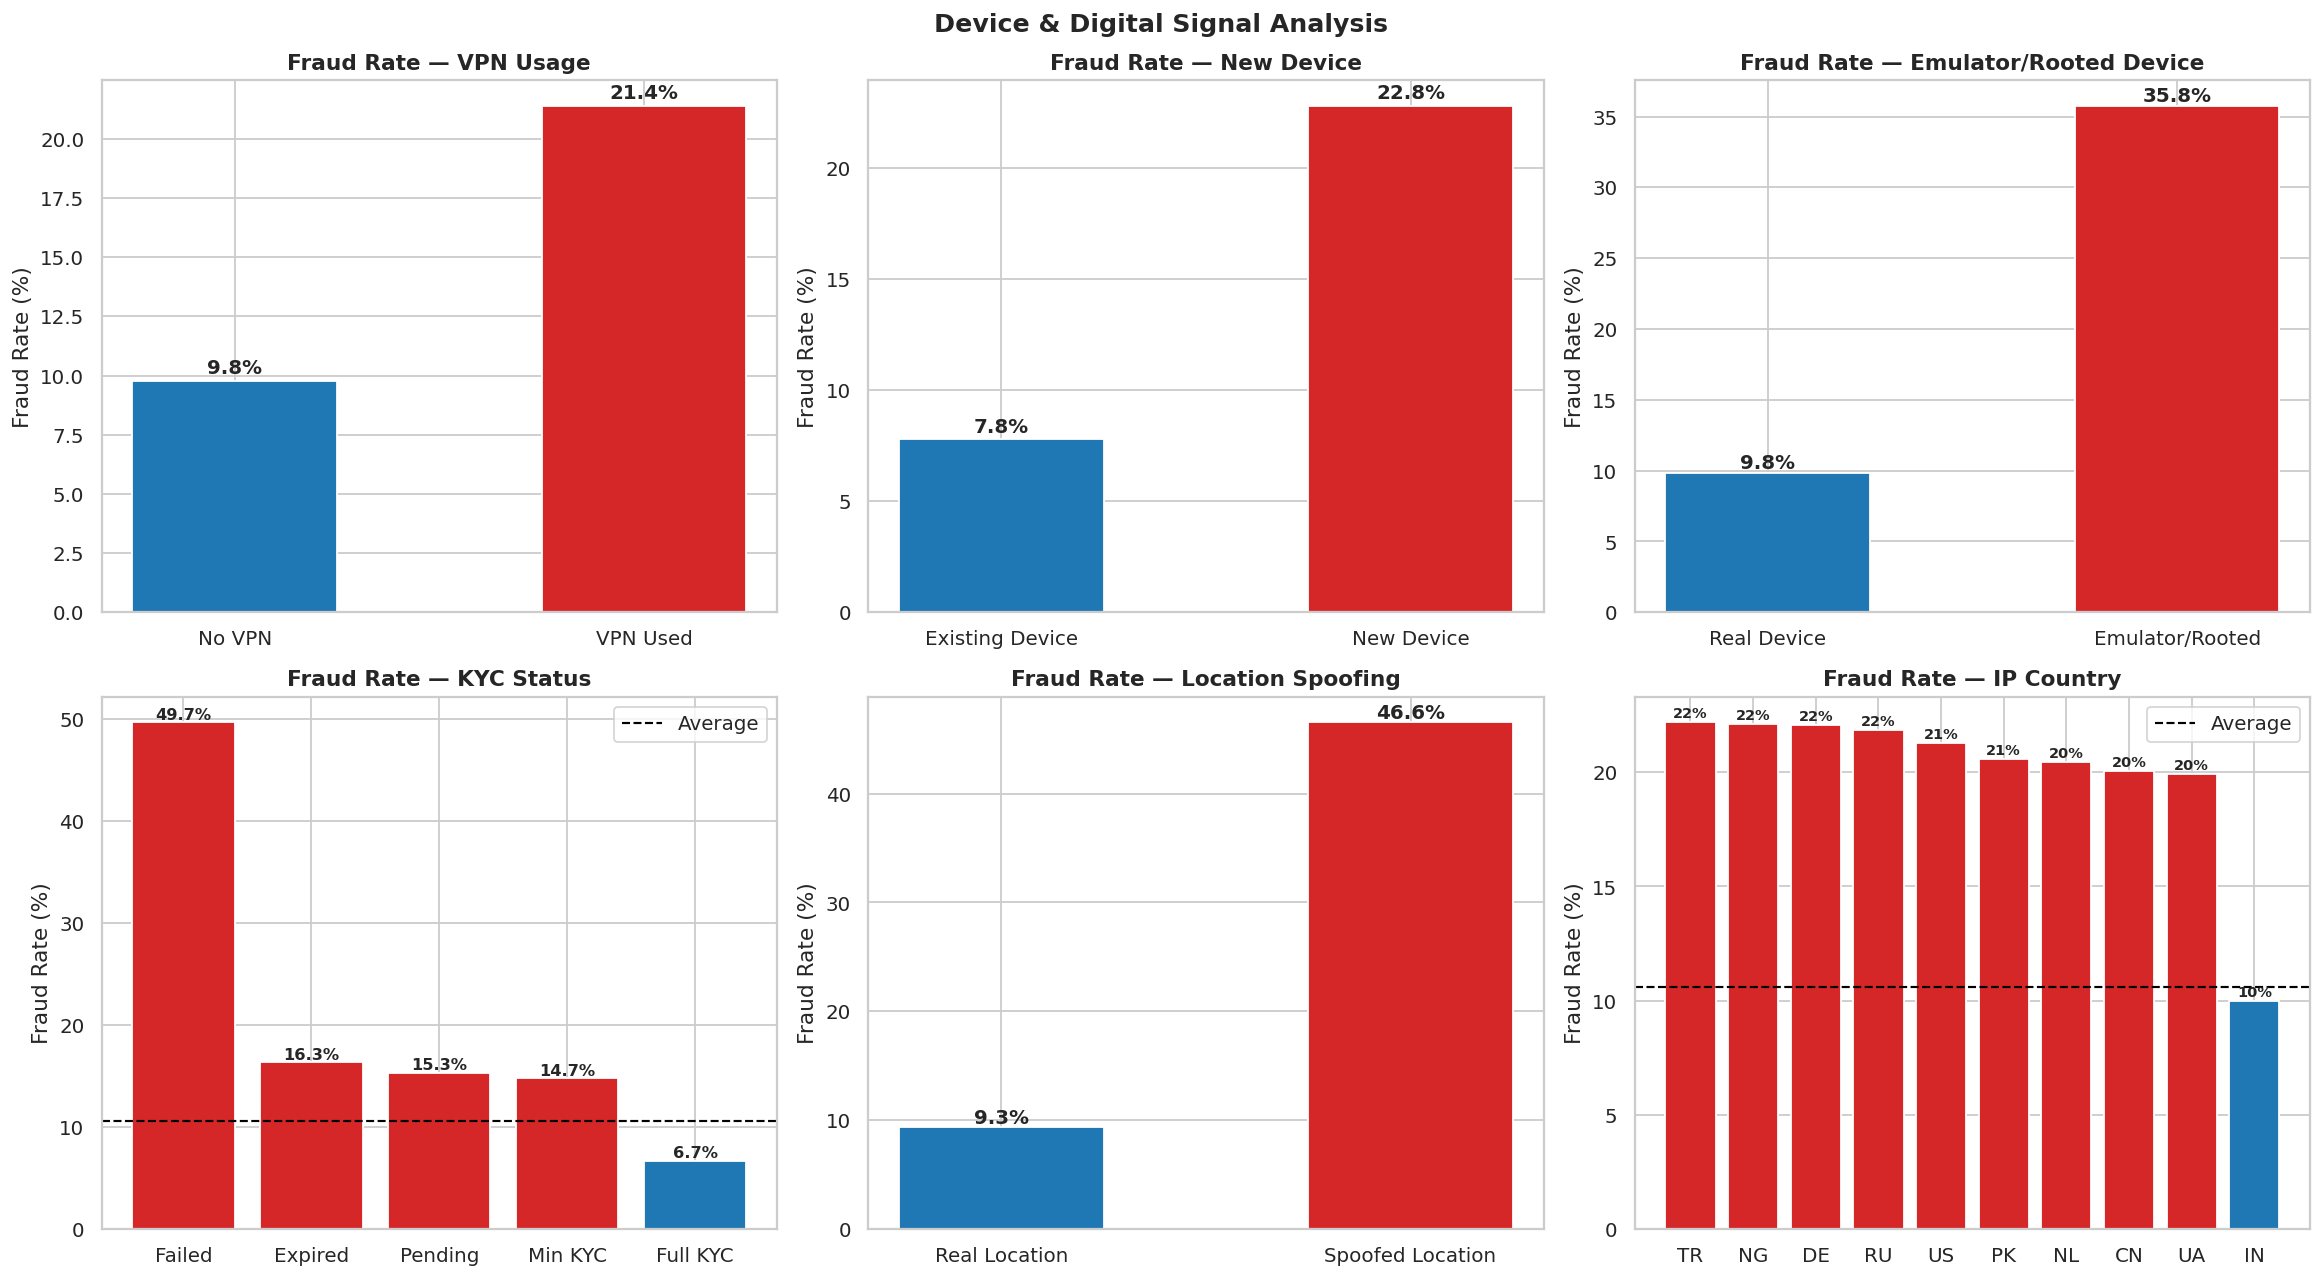


Device Signal Summary:
  VPN users fraud rate          : 21.4%  vs  9.8% non-VPN
  New device fraud rate         : 22.8%  vs  7.8% existing device
  Emulator/rooted fraud rate    : 35.8%  vs  9.8% real device
  Location spoofed fraud rate   : 46.6%  vs  9.3% real location


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. VPN flag
vpn = df.groupby('vpn_proxy_flag')['is_fraud'].mean() * 100
axes[0,0].bar(['No VPN','VPN Used'], vpn.values,
               color=['#1f77b4','#d62728'], width=0.5)
axes[0,0].set_title('Fraud Rate — VPN Usage', fontweight='bold')
axes[0,0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(vpn.values):
    axes[0,0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. New device flag
nd = df.groupby('is_new_device')['is_fraud'].mean() * 100
axes[0,1].bar(['Existing Device','New Device'], nd.values,
               color=['#1f77b4','#d62728'], width=0.5)
axes[0,1].set_title('Fraud Rate — New Device', fontweight='bold')
axes[0,1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(nd.values):
    axes[0,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Emulator flag
em = df.groupby('emulator_rooted_flag')['is_fraud'].mean() * 100
axes[0,2].bar(['Real Device','Emulator/Rooted'], em.values,
               color=['#1f77b4','#d62728'], width=0.5)
axes[0,2].set_title('Fraud Rate — Emulator/Rooted Device', fontweight='bold')
axes[0,2].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(em.values):
    axes[0,2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. KYC Status
kyc = df.groupby('kyc_status')['is_fraud'].mean().sort_values(ascending=False) * 100
colors = ['#d62728' if v > df['is_fraud'].mean()*100 else '#1f77b4' for v in kyc.values]
axes[1,0].bar(kyc.index, kyc.values, color=colors)
axes[1,0].set_title('Fraud Rate — KYC Status', fontweight='bold')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].axhline(df['is_fraud'].mean()*100, color='black',
                   linestyle='--', linewidth=1.2, label='Average')
axes[1,0].legend()
for i, v in enumerate(kyc.values):
    axes[1,0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 5. Location spoofed
ls = df.groupby('location_spoofed')['is_fraud'].mean() * 100
axes[1,1].bar(['Real Location','Spoofed Location'], ls.values,
               color=['#1f77b4','#d62728'], width=0.5)
axes[1,1].set_title('Fraud Rate — Location Spoofing', fontweight='bold')
axes[1,1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(ls.values):
    axes[1,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. IP Country
ip_fraud = df.groupby('ip_country')['is_fraud'].mean().sort_values(ascending=False) * 100
colors   = ['#d62728' if v > df['is_fraud'].mean()*100 else '#1f77b4' for v in ip_fraud.values]
axes[1,2].bar(ip_fraud.index, ip_fraud.values, color=colors)
axes[1,2].set_title('Fraud Rate — IP Country', fontweight='bold')
axes[1,2].set_ylabel('Fraud Rate (%)')
axes[1,2].axhline(df['is_fraud'].mean()*100, color='black',
                   linestyle='--', linewidth=1.2, label='Average')
axes[1,2].legend()
for i, v in enumerate(ip_fraud.values):
    axes[1,2].text(i, v+0.2, f'{v:.0f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Device & Digital Signal Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\nDevice Signal Summary:")
print(f"  VPN users fraud rate          : {vpn[1]:.1f}%  vs  {vpn[0]:.1f}% non-VPN")
print(f"  New device fraud rate         : {nd[1]:.1f}%  vs  {nd[0]:.1f}% existing device")
print(f"  Emulator/rooted fraud rate    : {em[1]:.1f}%  vs  {em[0]:.1f}% real device")
print(f"  Location spoofed fraud rate   : {ls[1]:.1f}%  vs  {ls[0]:.1f}% real location")

Device signals tell a much stronger story than bureau scores. While CIBIL score gap between fraud and legit was only 16 points, an emulator/rooted device shows a 3.7x higher fraud rate and location spoofing shows a 5x higher rate. This proves that real-time behavioural and device signals are far more predictive than static credit bureau data — which is exactly the direction Indian fintechs are moving with device fingerprinting and behavioural biometrics.

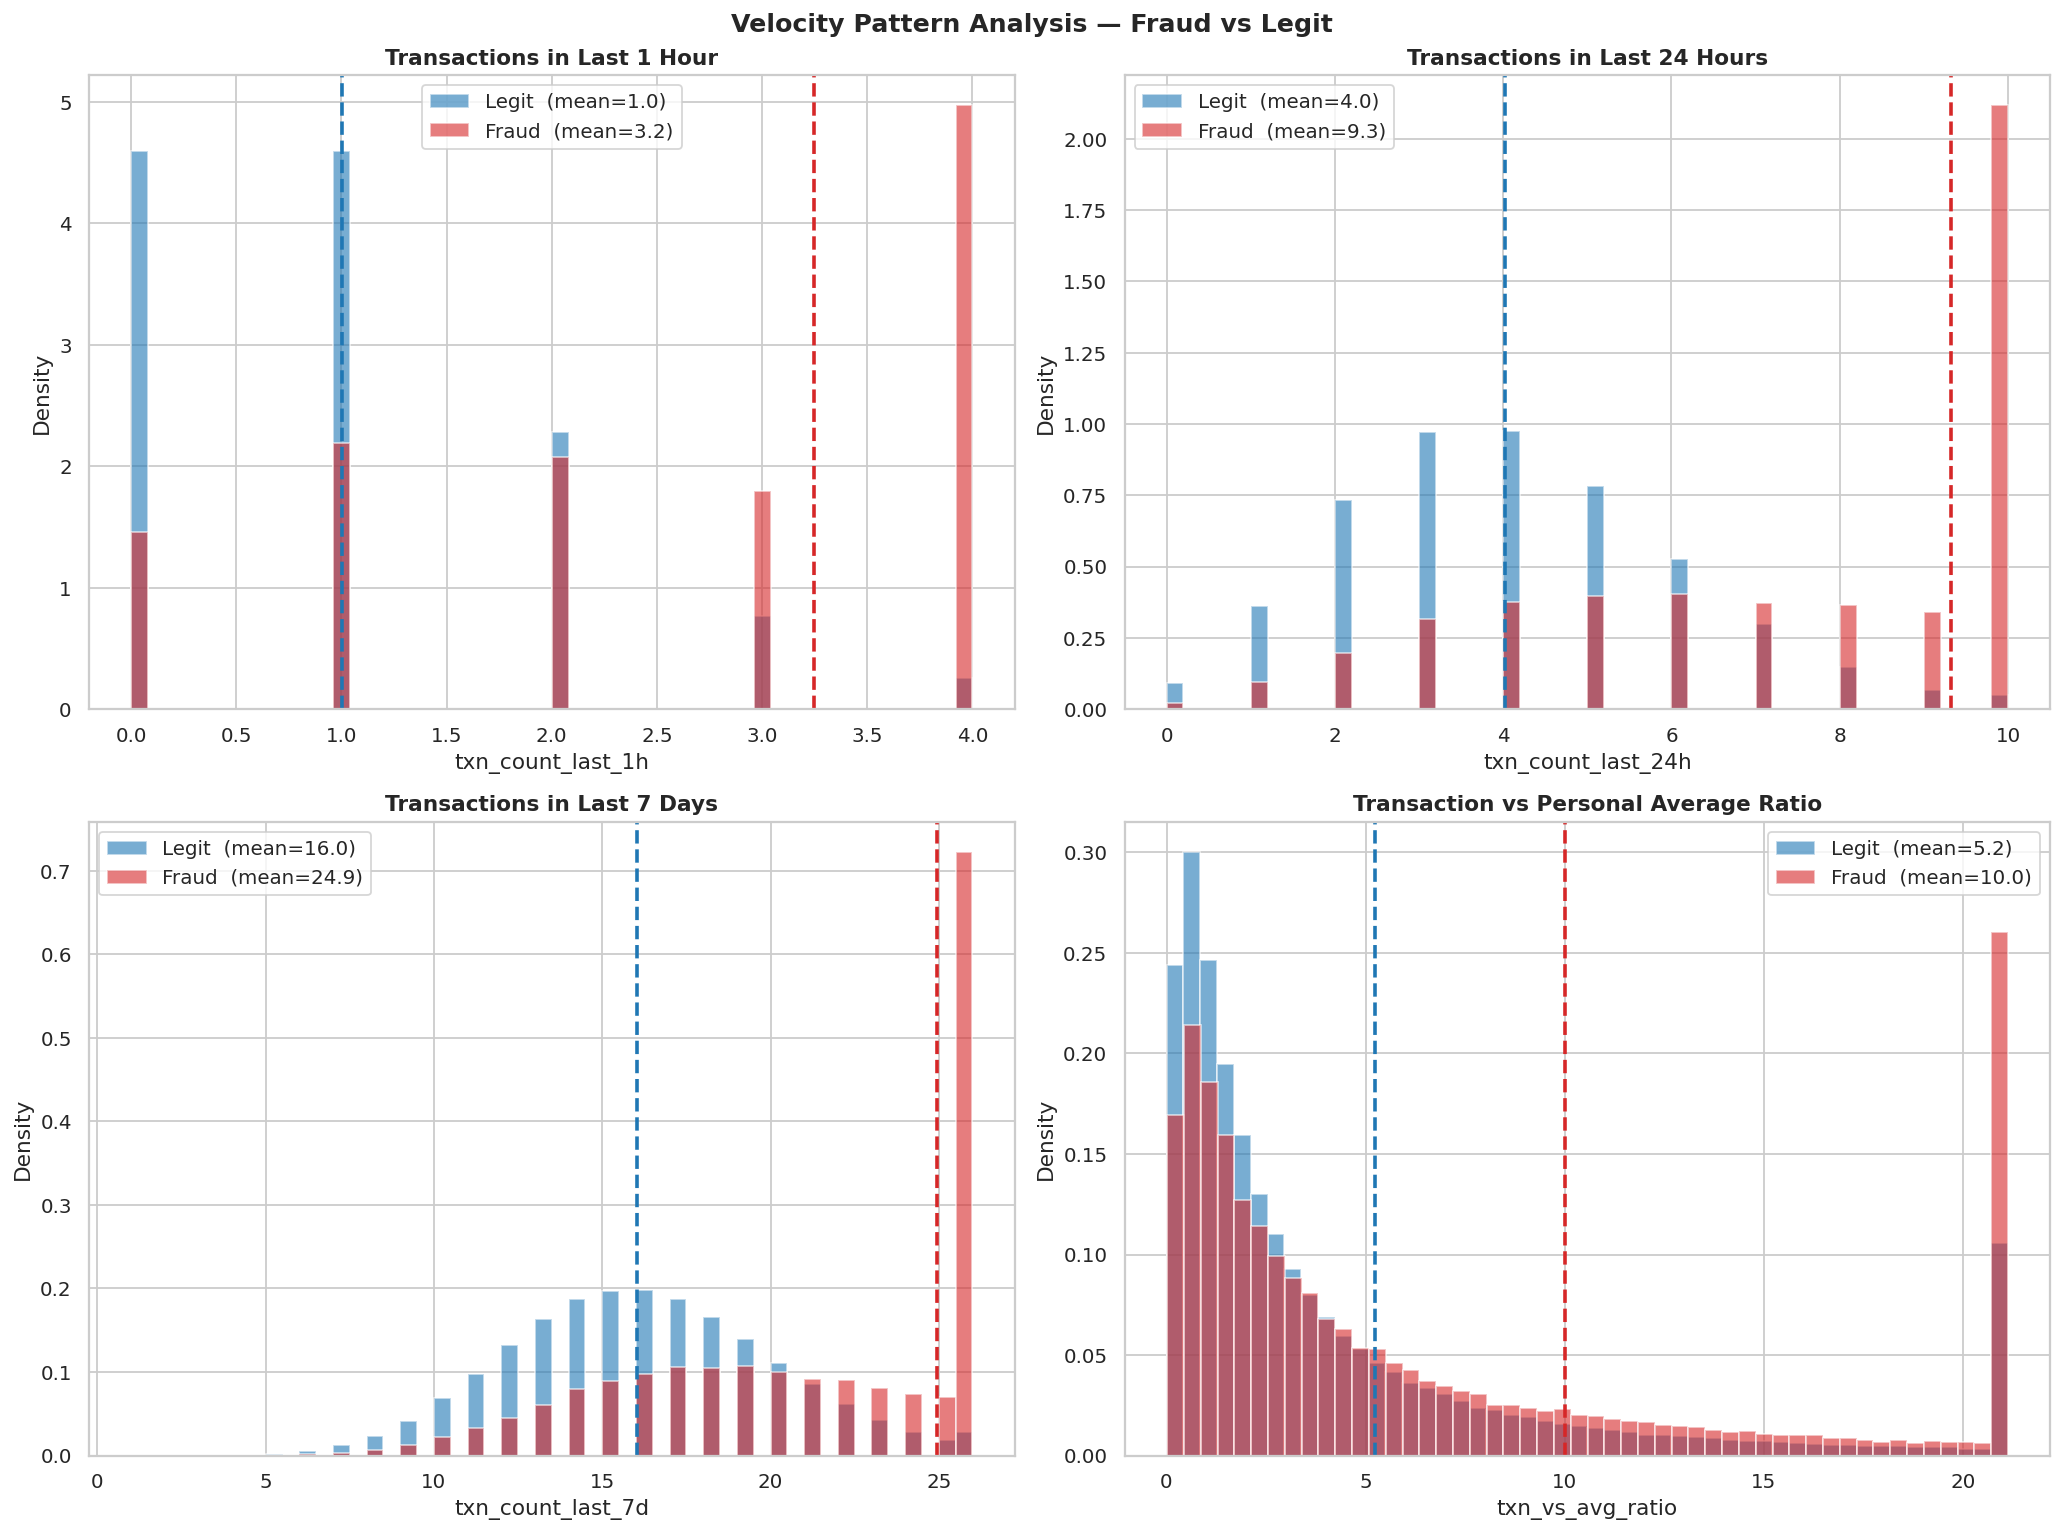


Velocity Feature Comparison:
Feature                        Legit Mean   Fraud Mean    Ratio
-----------------------------------------------------------------
txn_count_last_1h                    1.01         3.25     3.23x
txn_count_last_24h                   4.02         9.33     2.32x
txn_count_last_7d                   16.03        24.95     1.56x
txn_count_last_30d                  48.02        54.89     1.14x
txn_vs_avg_ratio                     5.24         9.99     1.91x
failed_txn_count_24h                 0.40         1.03     2.57x
diff_merchants_24h                   2.01         3.57     1.78x
diff_cities_7d                       1.00         1.78     1.77x


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

velocity_cols = [
    ('txn_count_last_1h',  'Transactions in Last 1 Hour'),
    ('txn_count_last_24h', 'Transactions in Last 24 Hours'),
    ('txn_count_last_7d',  'Transactions in Last 7 Days'),
    ('txn_vs_avg_ratio',   'Transaction vs Personal Average Ratio'),
]

for idx, (col, title) in enumerate(velocity_cols):
    ax = axes[idx//2][idx%2]

    fraud_vals = df[df['is_fraud']==1][col]
    legit_vals = df[df['is_fraud']==0][col]

    # Using 95th percentile as cap to avoid extreme outliers
    cap = df[col].quantile(0.95)

    ax.hist(legit_vals.clip(upper=cap), bins=50, alpha=0.6,
            color='#1f77b4', label=f'Legit  (mean={legit_vals.mean():.1f})',
            density=True)
    ax.hist(fraud_vals.clip(upper=cap), bins=50, alpha=0.6,
            color='#d62728', label=f'Fraud  (mean={fraud_vals.mean():.1f})',
            density=True)

    ax.axvline(legit_vals.mean(), color='#1f77b4', linestyle='--', linewidth=2)
    ax.axvline(fraud_vals.mean(), color='#d62728', linestyle='--', linewidth=2)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Velocity Pattern Analysis — Fraud vs Legit',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# actual means
print("\nVelocity Feature Comparison:")
print(f"{'Feature':<28} {'Legit Mean':>12} {'Fraud Mean':>12} {'Ratio':>8}")
print("-" * 65)
vel_cols = ['txn_count_last_1h','txn_count_last_24h',
            'txn_count_last_7d','txn_count_last_30d',
            'txn_vs_avg_ratio','failed_txn_count_24h',
            'diff_merchants_24h','diff_cities_7d']
for col in vel_cols:
    lm = df[df['is_fraud']==0][col].mean()
    fm = df[df['is_fraud']==1][col].mean()
    print(f"{col:<28} {lm:>12.2f} {fm:>12.2f} {fm/lm:>8.2f}x")

Velocity signals show a clear but noisy pattern. Short-term velocity — transactions in the last hour — shows the strongest fraud signal at 3.2x, consistent with card-testing behaviour where fraudsters make rapid small transactions to verify a stolen card. However 30-day velocity shows only 1.14x difference, making it nearly useless in isolation. Crucially, the **transaction-vs-personal-average ratio** at **1.91x** captures something raw counts miss — a ₹80,000 transaction from someone who averages ₹3,000 is far more suspicious than the same transaction from someone who regularly spends ₹60,000. This is why **personalised baselines outperform absolute thresholds** in fraud detection.

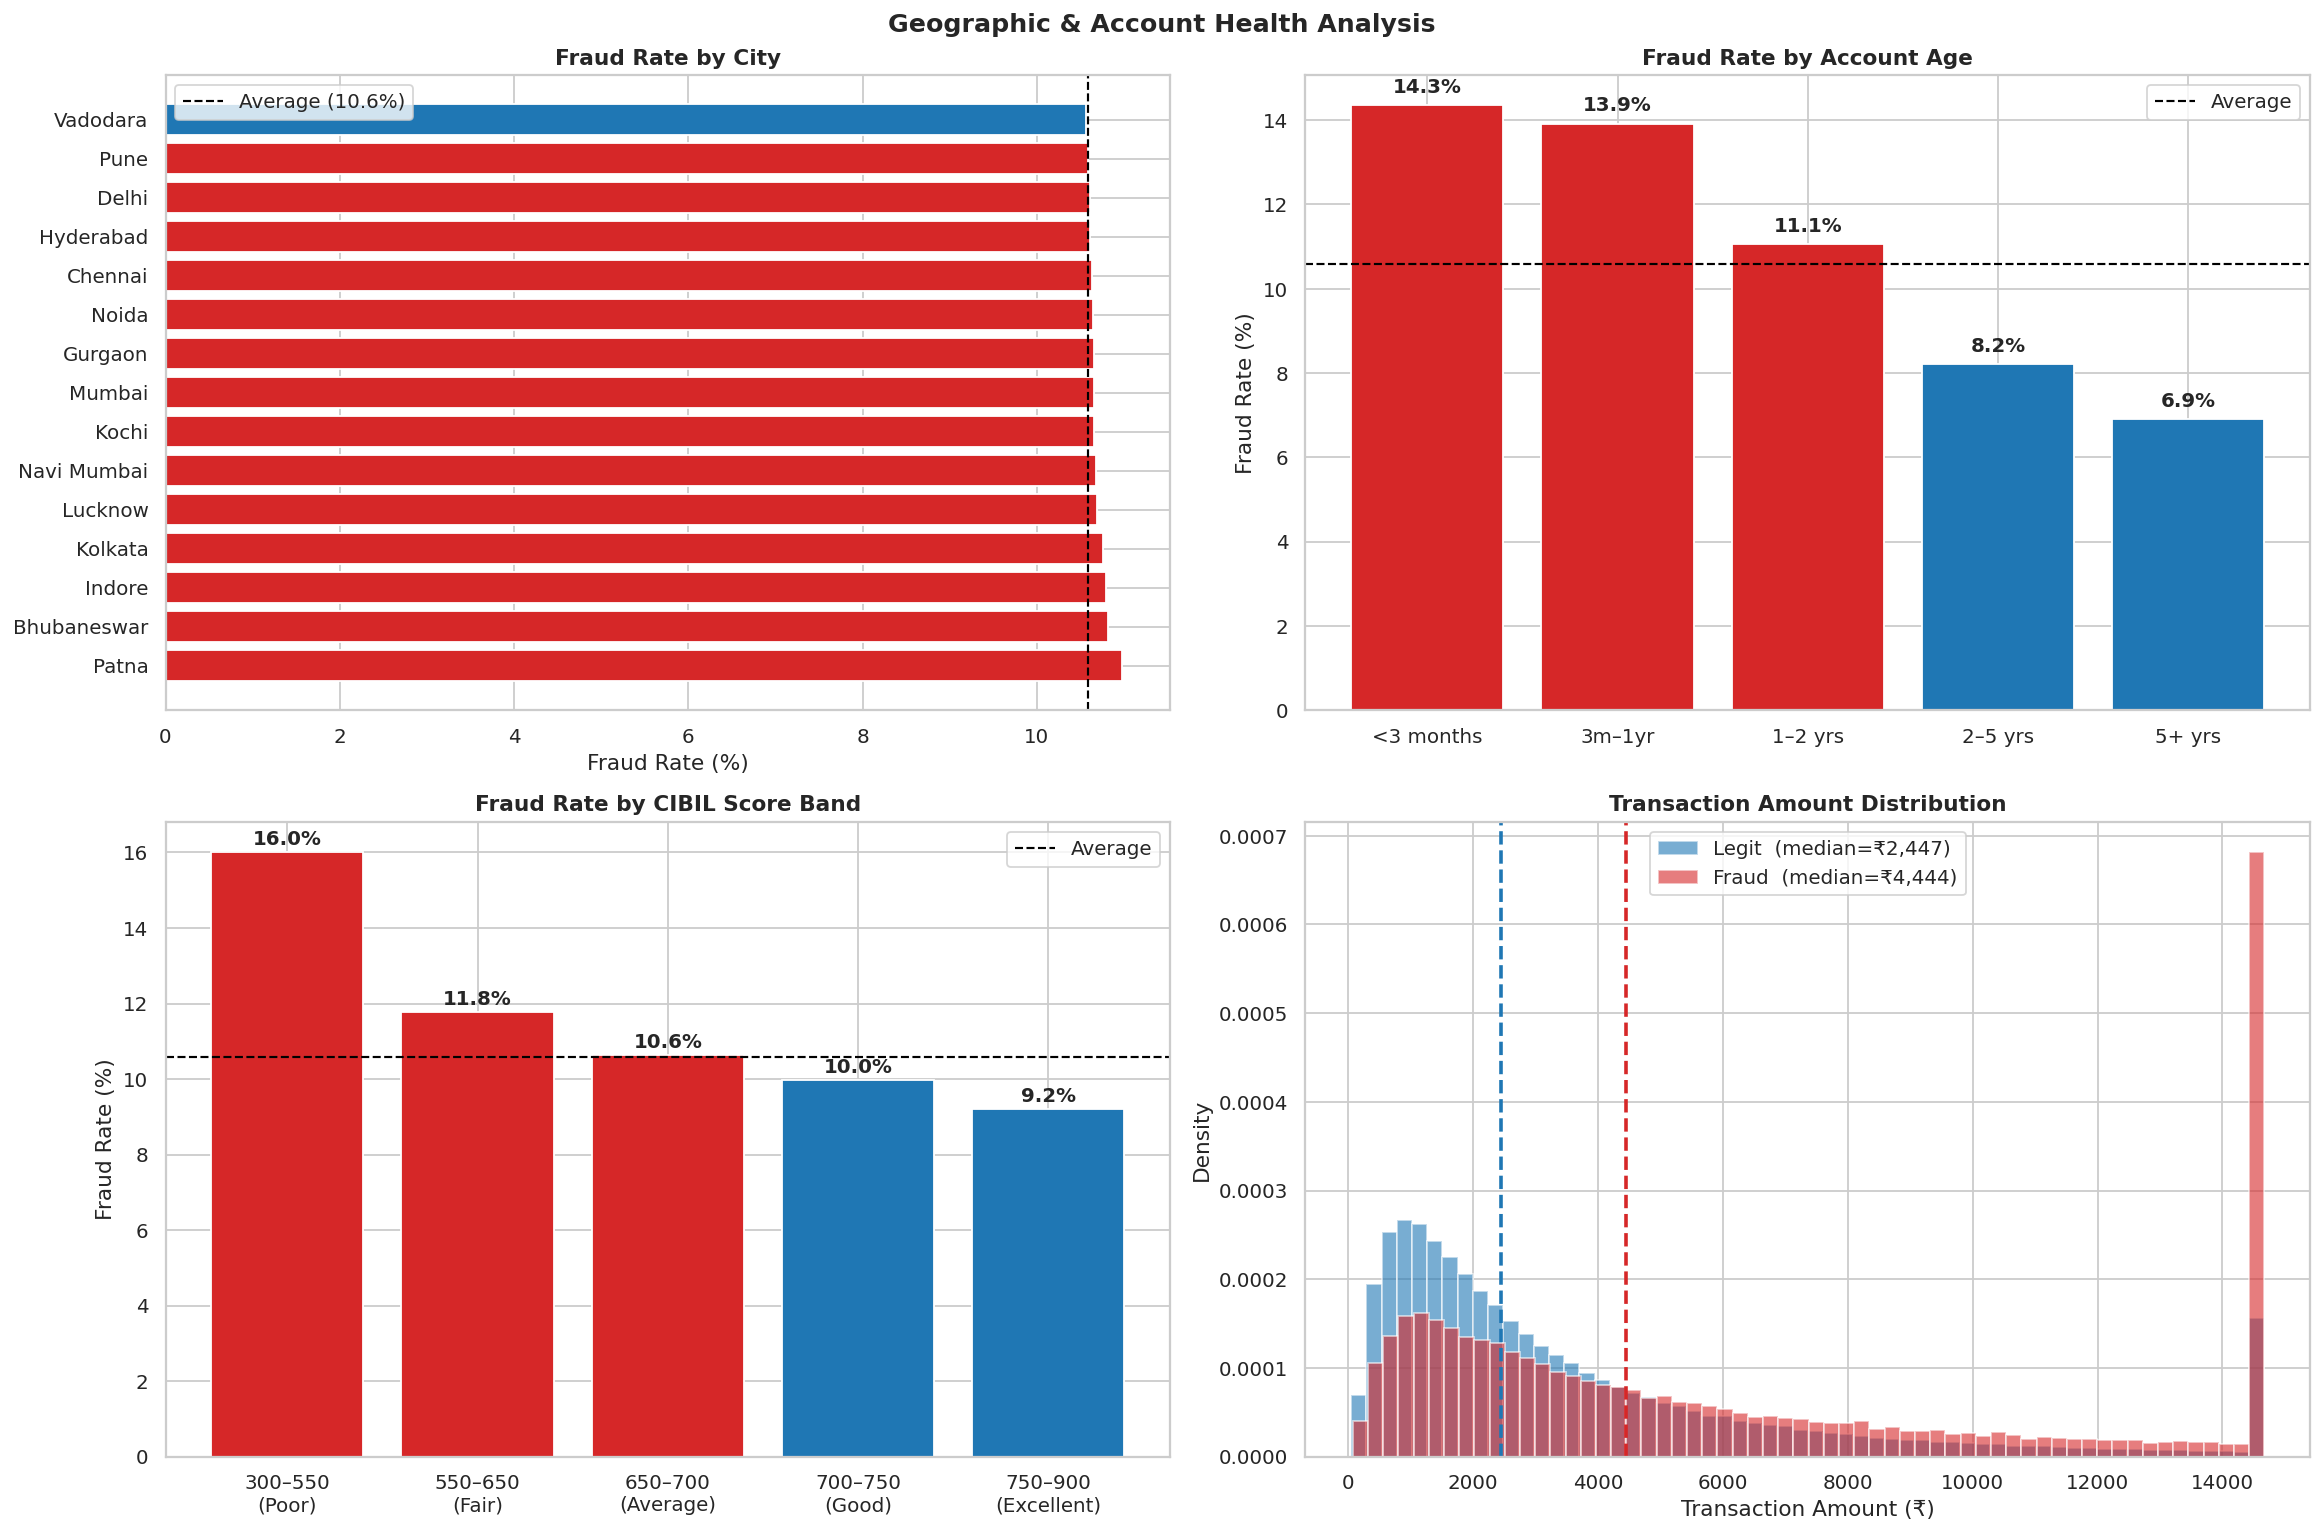


Key stats:
  Legit  median txn  : ₹     2,447
  Fraud  median txn  : ₹     4,444
  Legit  mean txn    : ₹     4,039
  Fraud  mean txn    : ₹     9,422

Account age fraud rates:
account_age_bucket
<3 months    14.3
3m–1yr       13.9
1–2 yrs      11.1
2–5 yrs       8.2
5+ yrs        6.9

CIBIL band fraud rates:
cibil_bucket
300–550\n(Poor)         16.0
550–650\n(Fair)         11.8
650–700\n(Average)      10.6
700–750\n(Good)         10.0
750–900\n(Excellent)     9.2


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Fraud rate by city — top 15
city_fraud = df.groupby('city').agg(
    total=('is_fraud','count'),
    fraud=('is_fraud','sum')
).reset_index()
city_fraud['fraud_rate_%'] = (city_fraud['fraud']/city_fraud['total']*100).round(2)
city_fraud = city_fraud.sort_values('fraud_rate_%', ascending=False).head(15)

avg_rate = df['is_fraud'].mean() * 100
colors   = ['#d62728' if x > avg_rate else '#1f77b4'
            for x in city_fraud['fraud_rate_%']]
axes[0,0].barh(city_fraud['city'], city_fraud['fraud_rate_%'], color=colors)
axes[0,0].axvline(avg_rate, color='black', linestyle='--',
                   linewidth=1.2, label=f'Average ({avg_rate:.1f}%)')
axes[0,0].set_title('Fraud Rate by City', fontweight='bold')
axes[0,0].set_xlabel('Fraud Rate (%)')
axes[0,0].legend()

# 2. Account age vs fraud
df['account_age_bucket'] = pd.cut(df['account_age_days'],
    bins=[0,90,365,730,1825,9125],
    labels=['<3 months','3m–1yr','1–2 yrs','2–5 yrs','5+ yrs'])
age_fraud = df.groupby('account_age_bucket', observed=True)['is_fraud'].mean() * 100
colors2   = ['#d62728' if x > avg_rate else '#1f77b4' for x in age_fraud.values]
axes[0,1].bar(age_fraud.index, age_fraud.values, color=colors2)
axes[0,1].axhline(avg_rate, color='black', linestyle='--', linewidth=1.2, label='Average')
axes[0,1].set_title('Fraud Rate by Account Age', fontweight='bold')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].legend()
for i, v in enumerate(age_fraud.values):
    axes[0,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. CIBIL score bucket vs fraud rate
df['cibil_bucket'] = pd.cut(df['cibil_score'],
    bins=[300,550,650,700,750,900],
    labels=['300–550\n(Poor)','550–650\n(Fair)',
            '650–700\n(Average)','700–750\n(Good)','750–900\n(Excellent)'])
cibil_fraud = df.groupby('cibil_bucket', observed=True)['is_fraud'].mean() * 100
colors3     = ['#d62728' if x > avg_rate else '#1f77b4' for x in cibil_fraud.values]
axes[1,0].bar(cibil_fraud.index, cibil_fraud.values, color=colors3)
axes[1,0].axhline(avg_rate, color='black', linestyle='--', linewidth=1.2, label='Average')
axes[1,0].set_title('Fraud Rate by CIBIL Score Band', fontweight='bold')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].legend()
for i, v in enumerate(cibil_fraud.values):
    axes[1,0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. Transaction amount distribution
fraud_amt = df[df['is_fraud']==1]['txn_amount']
legit_amt = df[df['is_fraud']==0]['txn_amount']
cap_amt   = df['txn_amount'].quantile(0.95)

axes[1,1].hist(legit_amt.clip(upper=cap_amt), bins=60, alpha=0.6,
               color='#1f77b4', density=True,
               label=f'Legit  (median=₹{legit_amt.median():,.0f})')
axes[1,1].hist(fraud_amt.clip(upper=cap_amt), bins=60, alpha=0.6,
               color='#d62728', density=True,
               label=f'Fraud  (median=₹{fraud_amt.median():,.0f})')
axes[1,1].axvline(legit_amt.median(), color='#1f77b4', linestyle='--', linewidth=2)
axes[1,1].axvline(fraud_amt.median(), color='#d62728', linestyle='--', linewidth=2)
axes[1,1].set_title('Transaction Amount Distribution', fontweight='bold')
axes[1,1].set_xlabel('Transaction Amount (₹)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.suptitle('Geographic & Account Health Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey stats:")
print(f"  Legit  median txn  : ₹{legit_amt.median():>10,.0f}")
print(f"  Fraud  median txn  : ₹{fraud_amt.median():>10,.0f}")
print(f"  Legit  mean txn    : ₹{legit_amt.mean():>10,.0f}")
print(f"  Fraud  mean txn    : ₹{fraud_amt.mean():>10,.0f}")
print(f"\nAccount age fraud rates:")
print(age_fraud.round(1).to_string())
print(f"\nCIBIL band fraud rates:")
print(cibil_fraud.round(1).to_string())

Our analysis of 400,000 transactions revealed that fraud is fundamentally a multi-signal problem. No single feature reliably separates fraud from legitimate transactions.
Temporally, fraud peaks between 2–4AM at 21.7% — more than double the daily average — but also spikes at 9.3% during business hours due to account takeover fraud that deliberately mimics normal behaviour.
Geographically, fraud is distributed uniformly across Indian cities — there is no high-risk city. However merchant category matters significantly — Luxury Goods at 17.5% and Jewellery at 13.5% are the riskiest categories despite being among the lowest volume.
Bureau scores show only a 16-point CIBIL gap between fraud and legit — statistically almost useless alone. But account age tells a much stronger story — accounts under 3 months have 14.3% fraud rate versus 6.9% for accounts over 5 years.
Device signals are the strongest individual indicators — emulator/rooted devices show 35.8% fraud rate and location spoofing reaches 46.6% — both nearly 4–5x the average. But even these can't be used as hard blocks since legitimate users occasionally trigger these signals.
This proves why a machine learning approach is necessary — fraud is only detectable when multiple weak signals are combined simultaneously. No single rule catches it. This is precisely what XGBoost does.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── Dropping columns useless for model
drop_cols = [
    'transaction_id','user_id','session_id',
    'device_fingerprint','digital_signature',
    'ip_address','card_last4','card_bin',
    'card_expiry','merchant_id',
    'account_age_bucket','cibil_bucket'
]
df_model = df.drop(columns=drop_cols)

# ── Filling UPI nulls
df_model['upi_id'] = df_model['upi_id'].fillna('NOT_UPI')

# ── Encoding categoricals
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ── Split
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=57
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"Fraud in train: {y_train.sum():,}  ({y_train.mean()*100:.1f}%)")

X_train : (320000, 77)
X_test  : (80000, 77)
Features: 77
Fraud in train: 33,865  (10.6%)


In [10]:
smote = SMOTE(random_state=57)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE → {y_train.value_counts().to_dict()}")
print(f"After SMOTE  → {pd.Series(y_train_res).value_counts().to_dict()}")
print(f"New training size: {X_train_res.shape}")

Before SMOTE → {0: 286135, 1: 33865}
After SMOTE  → {0: 286135, 1: 286135}
New training size: (572270, 77)


In [11]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='auc',
    random_state=57,
    n_jobs=-1
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Model training complete")

[0]	validation_0-auc:0.85112
[50]	validation_0-auc:0.88167
[100]	validation_0-auc:0.88496
[150]	validation_0-auc:0.88555
[200]	validation_0-auc:0.88580
[250]	validation_0-auc:0.88628
[299]	validation_0-auc:0.88647
Model training complete


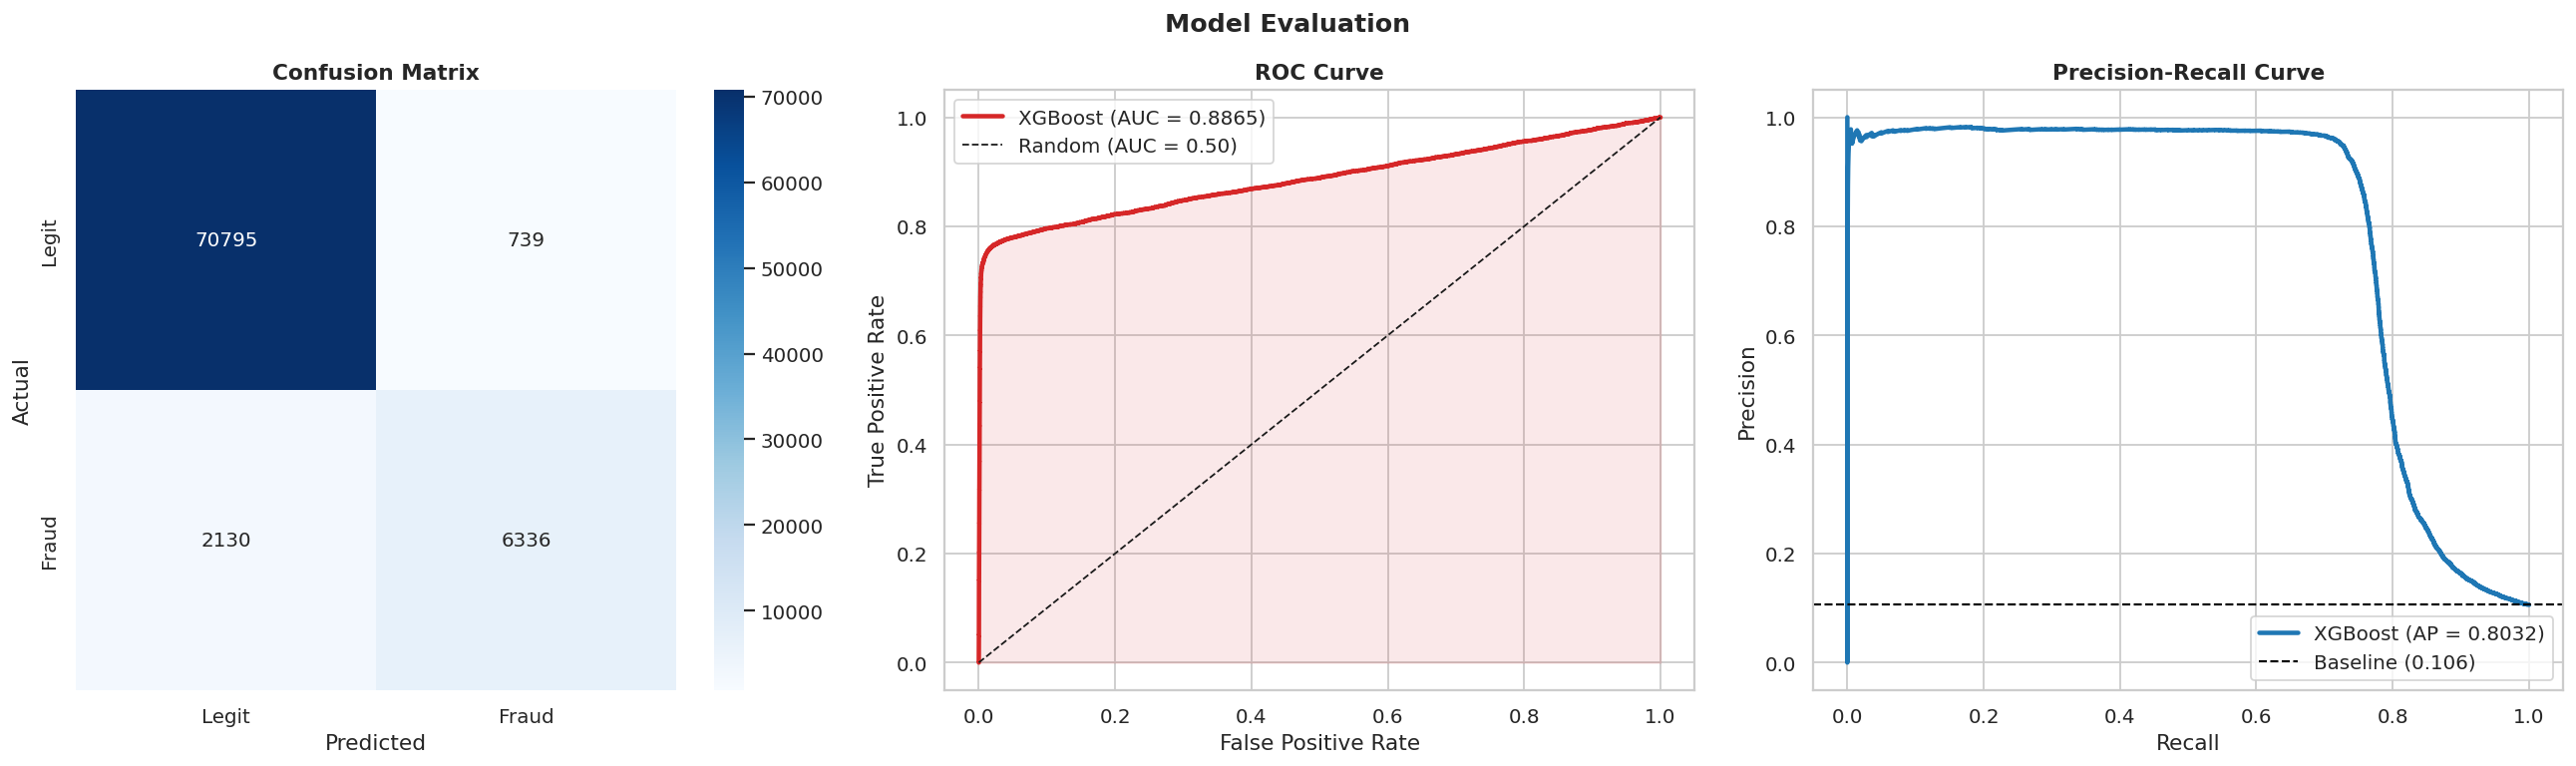

              precision    recall  f1-score   support

       Legit       0.97      0.99      0.98     71534
       Fraud       0.90      0.75      0.82      8466

    accuracy                           0.96     80000
   macro avg       0.93      0.87      0.90     80000
weighted avg       0.96      0.96      0.96     80000

ROC-AUC Score     : 0.8865
Average Precision : 0.8032

Confusion Matrix Breakdown:
  True Negatives  (Legit correctly cleared) : 70,795
  False Positives (Legit wrongly blocked)   : 739
  False Negatives (Fraud missed)            : 2,130  ← most critical
  True Positives  (Fraud caught)            : 6,336

  Fraud Catch Rate  : 74.8%
  False Alarm Rate  : 1.03%


In [12]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ── Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#d62728', linewidth=2.5,
             label=f'XGBoost (AUC = {auc_score:.4f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#d62728')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# ── Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)
axes[2].plot(recall, precision, color='#1f77b4', linewidth=2.5,
             label=f'XGBoost (AP = {ap_score:.4f})')
axes[2].axhline(y_test.mean(), color='black', linestyle='--',
                linewidth=1.2, label=f'Baseline ({y_test.mean():.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── full report
print(classification_report(y_test, y_pred,
      target_names=['Legit','Fraud']))
print(f"ROC-AUC Score     : {auc_score:.4f}")
print(f"Average Precision : {ap_score:.4f}")

# ── Key numbers
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (Legit correctly cleared) : {tn:,}")
print(f"  False Positives (Legit wrongly blocked)   : {fp:,}")
print(f"  False Negatives (Fraud missed)            : {fn:,}  ← most critical")
print(f"  True Positives  (Fraud caught)            : {tp:,}")
print(f"\n  Fraud Catch Rate  : {tp/(tp+fn)*100:.1f}%")
print(f"  False Alarm Rate  : {fp/(fp+tn)*100:.2f}%")

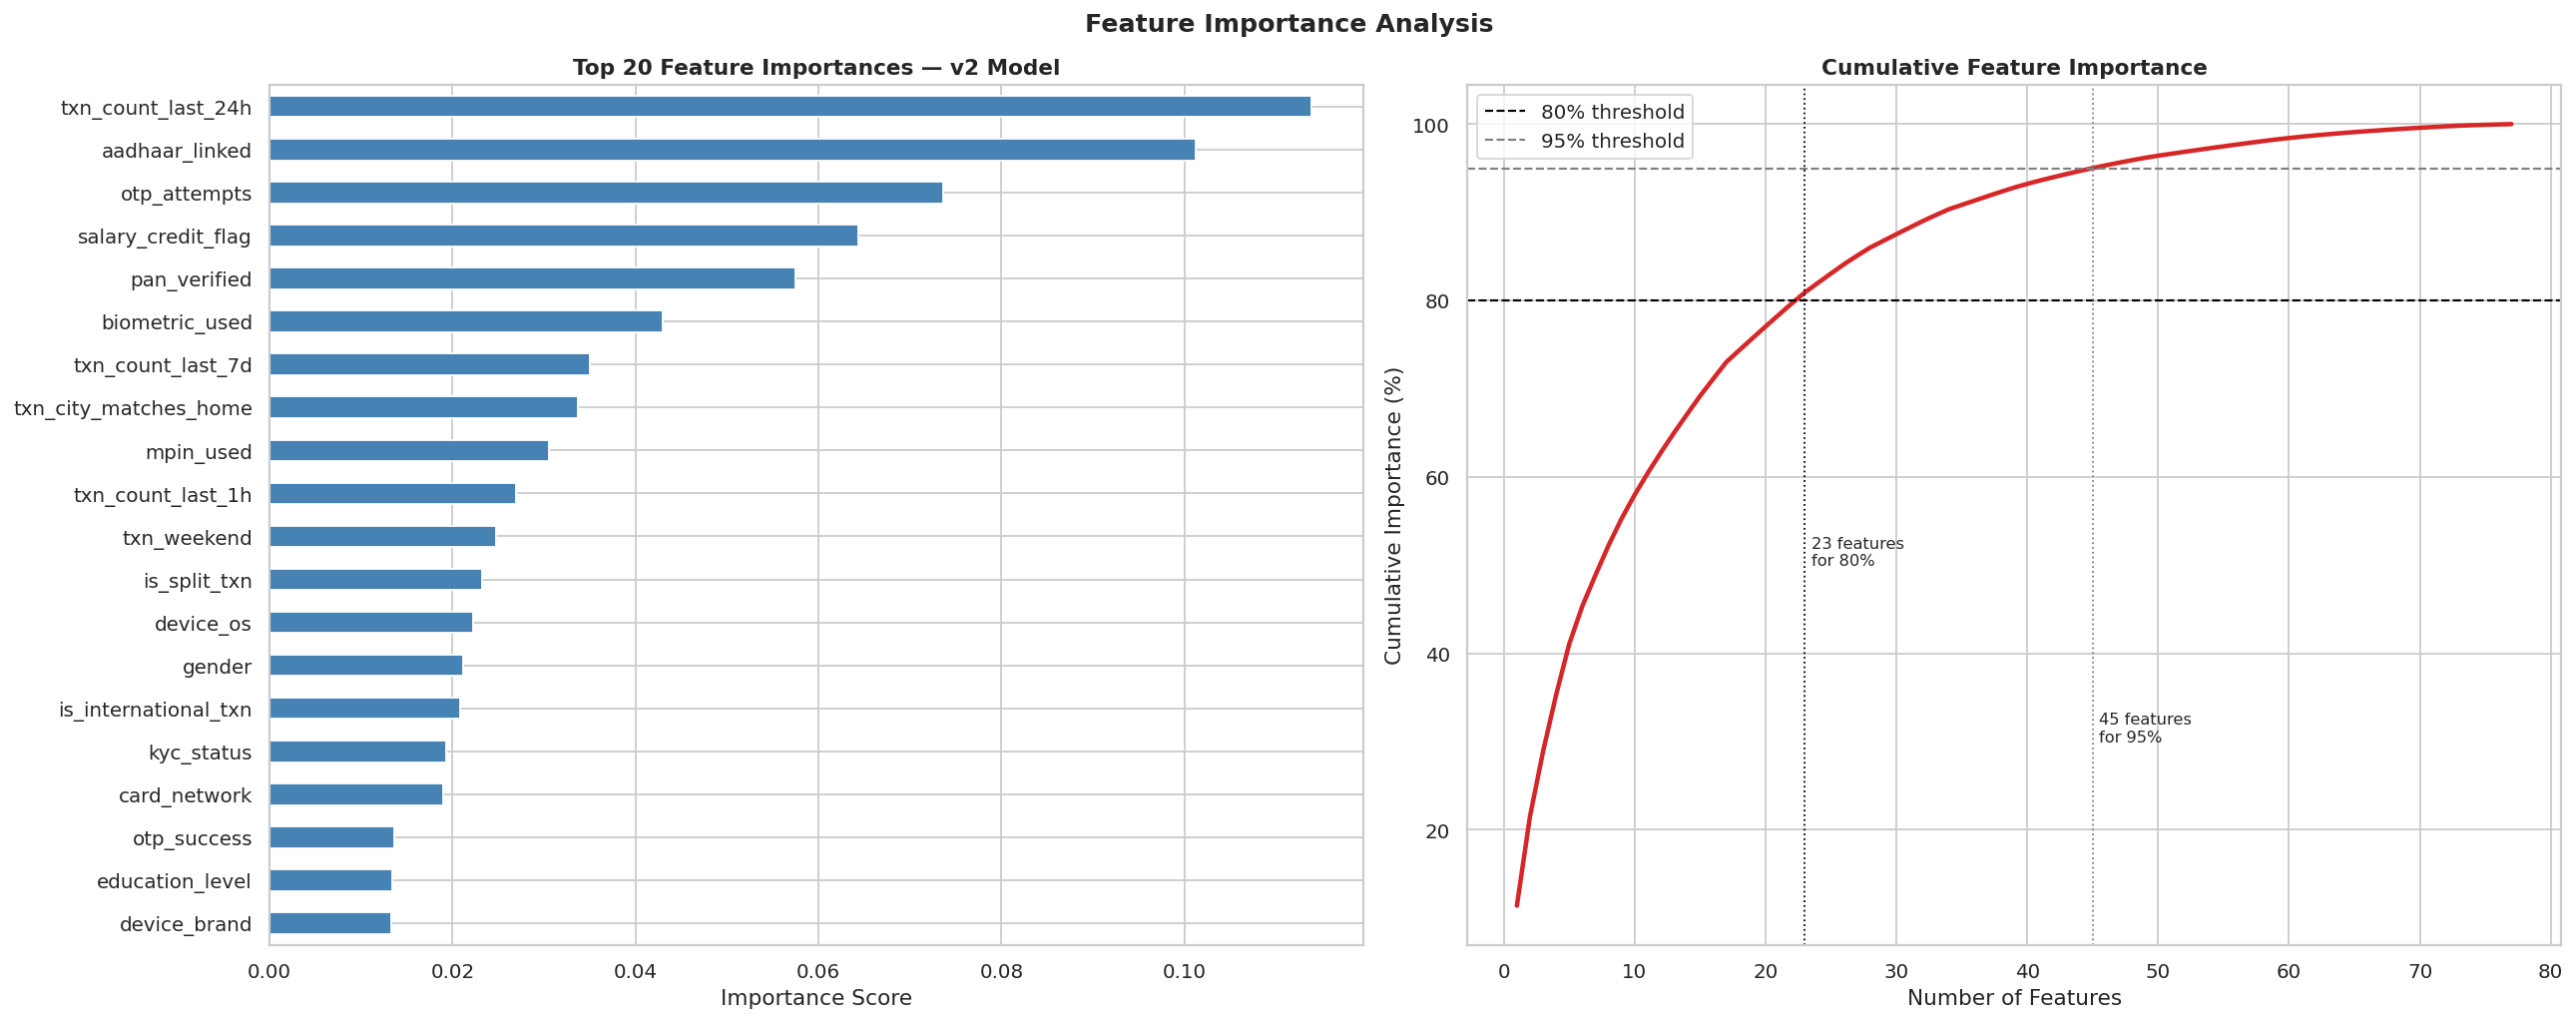

Top 15 Features:
Rank   Feature                          Importance   Cumulative %
-----------------------------------------------------------------
1      txn_count_last_24h                   0.1139          11.4%
2      aadhaar_linked                       0.1013          21.5%
3      otp_attempts                         0.0736          28.9%
4      salary_credit_flag                   0.0644          35.3%
5      pan_verified                         0.0575          41.1%
6      biometric_used                       0.0429          45.4%
7      txn_count_last_7d                    0.0350          48.9%
8      txn_city_matches_home                0.0336          52.2%
9      mpin_used                            0.0306          55.3%
10     txn_count_last_1h                    0.0270          58.0%
11     txn_weekend                          0.0247          60.4%
12     is_split_txn                         0.0232          62.8%
13     device_os                            0.0222         

In [13]:
feat_imp = pd.Series(model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top 20 features
feat_imp.head(20).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Top 20 Feature Importances — v2 Model', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Cumulative importance
cumulative = feat_imp.values.cumsum() / feat_imp.values.sum() * 100
axes[1].plot(range(1, len(cumulative)+1), cumulative,
             color='#d62728', linewidth=2.5)
axes[1].axhline(80, color='black', linestyle='--',
                linewidth=1.2, label='80% threshold')
axes[1].axhline(95, color='grey', linestyle='--',
                linewidth=1.2, label='95% threshold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()

# Marking where 80% and 95% are reached
idx_80 = next(i for i, v in enumerate(cumulative) if v >= 80) + 1
idx_95 = next(i for i, v in enumerate(cumulative) if v >= 95) + 1
axes[1].axvline(idx_80, color='black', linestyle=':', linewidth=1)
axes[1].axvline(idx_95, color='grey', linestyle=':', linewidth=1)
axes[1].text(idx_80+0.5, 50, f'{idx_80} features\nfor 80%', fontsize=9)
axes[1].text(idx_95+0.5, 30, f'{idx_95} features\nfor 95%', fontsize=9)

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top 15 with percentage
print("Top 15 Features:")
print(f"{'Rank':<6} {'Feature':<30} {'Importance':>12} {'Cumulative %':>14}")
print("-" * 65)
cumsum = 0
for rank, (feat, imp) in enumerate(feat_imp.head(15).items(), 1):
    cumsum += imp / feat_imp.sum() * 100
    print(f"{rank:<6} {feat:<30} {imp:>12.4f} {cumsum:>13.1f}%")

# The critical comparison
print(f"\n{'─'*50}")
print(f"top feature share  →  {feat_imp.iloc[0]/feat_imp.sum()*100:.1f}%  ({feat_imp.index[0]})")
print(f"{'─'*50}")

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

param_dist = {
    'n_estimators':      [200, 300, 500, 700],
    'max_depth':         [4, 5, 6, 7, 8],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.3],
}

base_xgb = XGBClassifier(
    eval_metric='auc',
    random_state=57,
    n_jobs=-1,
    device='cuda',
    tree_method='hist'

)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=40,              # try 40 random combinations
    scoring='roc_auc',
    cv=3,                   # 3-fold cross validation
    verbose=2,
    random_state=57,
    n_jobs=-1
)

print("Starting RandomizedSearchCV — 40 iterations × 3 folds = 120 fits")


search.fit(X_train_res, y_train_res)

print(f"\nBest ROC-AUC (CV): {search.best_score_:.4f}")
print(f"Best Parameters:")
for param, value in search.best_params_.items():
    print(f"   {param:<22} : {value}")

Starting RandomizedSearchCV — 40 iterations × 3 folds = 120 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best ROC-AUC (CV): 0.9842
Best Parameters:
   subsample              : 0.9
   n_estimators           : 300
   min_child_weight       : 3
   max_depth              : 8
   learning_rate          : 0.05
   gamma                  : 0
   colsample_bytree       : 0.9


[0]	validation_0-auc:0.84849
[50]	validation_0-auc:0.88321
[100]	validation_0-auc:0.88604
[150]	validation_0-auc:0.88670
[200]	validation_0-auc:0.88713
[250]	validation_0-auc:0.88745
[299]	validation_0-auc:0.88769


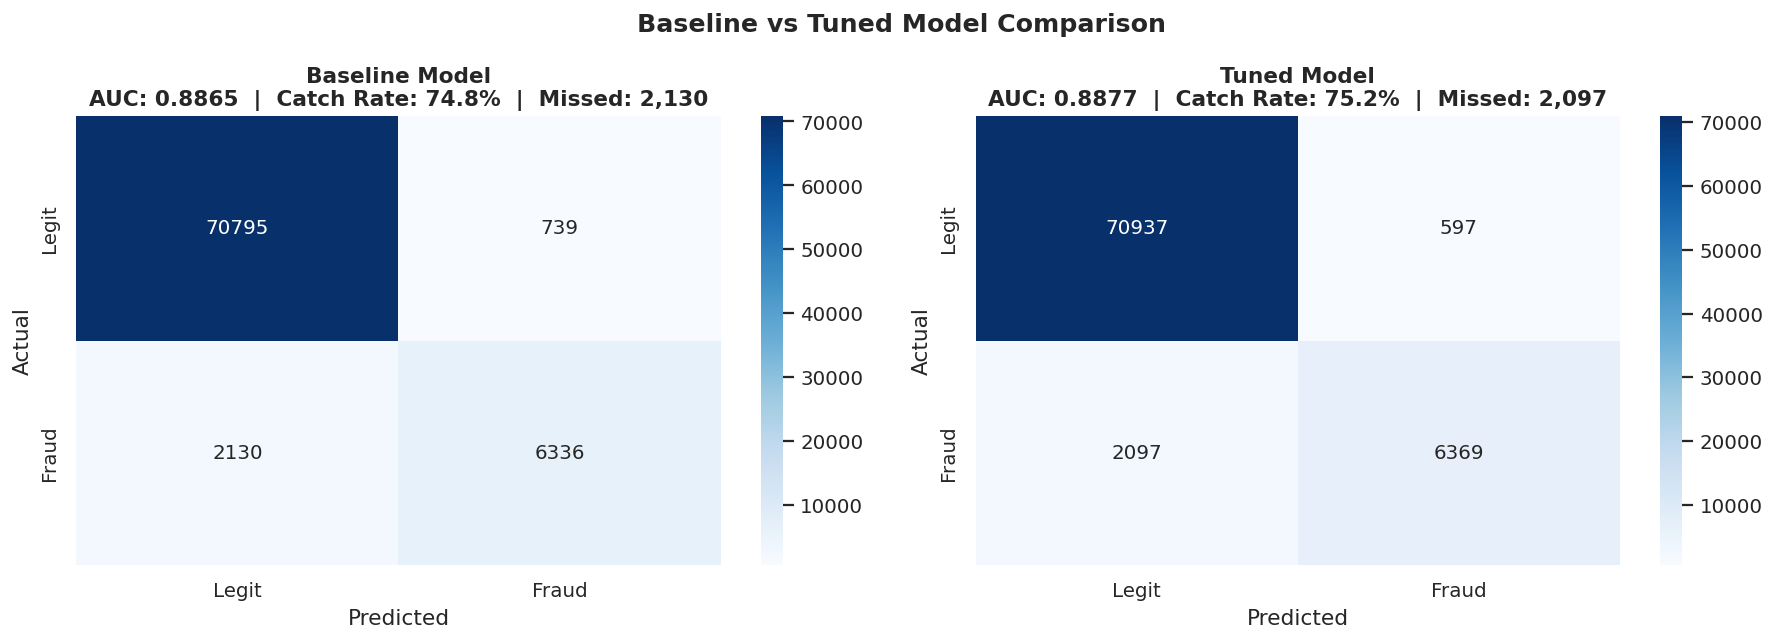


 Model Comparison:
Metric                           Baseline        Tuned     Change
─────────────────────────────────────────────────────────────────
ROC-AUC                            0.8865       0.8877 +   0.0012
Fraud Catch Rate                    74.8%        75.2% +     0.4%
Fraud Caught                    6336.0000    6369.0000 +  33.0000
Fraud Missed                    2130.0000    2097.0000  -33.0000
False Alarms                     739.0000     597.0000 -142.0000
False Alarm Rate                     1.0%         0.8%     -0.2%


In [15]:
from sklearn.metrics import recall_score

# Train tuned model with best parameters
tuned_model = XGBClassifier(
    **search.best_params_,
    eval_metric='auc',
    random_state=57,
    n_jobs=-1,
    device='cuda',
    tree_method='hist'
)

tuned_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# ── Evaluate both models side by side
baseline_proba = model.predict_proba(X_test)[:,1]
tuned_proba    = tuned_model.predict_proba(X_test)[:,1]

baseline_pred  = model.predict(X_test)
tuned_pred     = tuned_model.predict(X_test)

b_auc  = roc_auc_score(y_test, baseline_proba)
t_auc  = roc_auc_score(y_test, tuned_proba)

b_catch = recall_score(y_test, baseline_pred)
t_catch = recall_score(y_test, tuned_pred)

b_cm   = confusion_matrix(y_test, baseline_pred)
t_cm   = confusion_matrix(y_test, tuned_pred)

# ── Side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, auc, catch in zip(
    axes,
    [b_cm, t_cm],
    ['Baseline Model', 'Tuned Model'],
    [b_auc, t_auc],
    [b_catch, t_catch]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{title}\nAUC: {auc:.4f}  |  Catch Rate: {catch*100:.1f}%  '
        f'|  Missed: {fn:,}',
        fontweight='bold'
    )
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Baseline vs Tuned Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print comparison table
print("\n Model Comparison:")
print(f"{'Metric':<28} {'Baseline':>12} {'Tuned':>12} {'Change':>10}")
print("─" * 65)

tn_b, fp_b, fn_b, tp_b = b_cm.ravel()
tn_t, fp_t, fn_t, tp_t = t_cm.ravel()

metrics = [
    ('ROC-AUC',          b_auc,           t_auc,           ''),
    ('Fraud Catch Rate', b_catch*100,      t_catch*100,     '%'),
    ('Fraud Caught',     tp_b,             tp_t,            ''),
    ('Fraud Missed',     fn_b,             fn_t,            ''),
    ('False Alarms',     fp_b,             fp_t,            ''),
    ('False Alarm Rate', fp_b/(fp_b+tn_b)*100, fp_t/(fp_t+tn_t)*100, '%'),
]

for name, bval, tval, unit in metrics:
    change = tval - bval
    sign   = '+' if change > 0 else ''
    if unit == '%':
        print(f"{name:<28} {bval:>11.1f}% {tval:>11.1f}% {sign}{change:>8.1f}%")
    else:
        print(f"{name:<28} {bval:>12.4f} {tval:>12.4f} {sign}{change:>9.4f}")

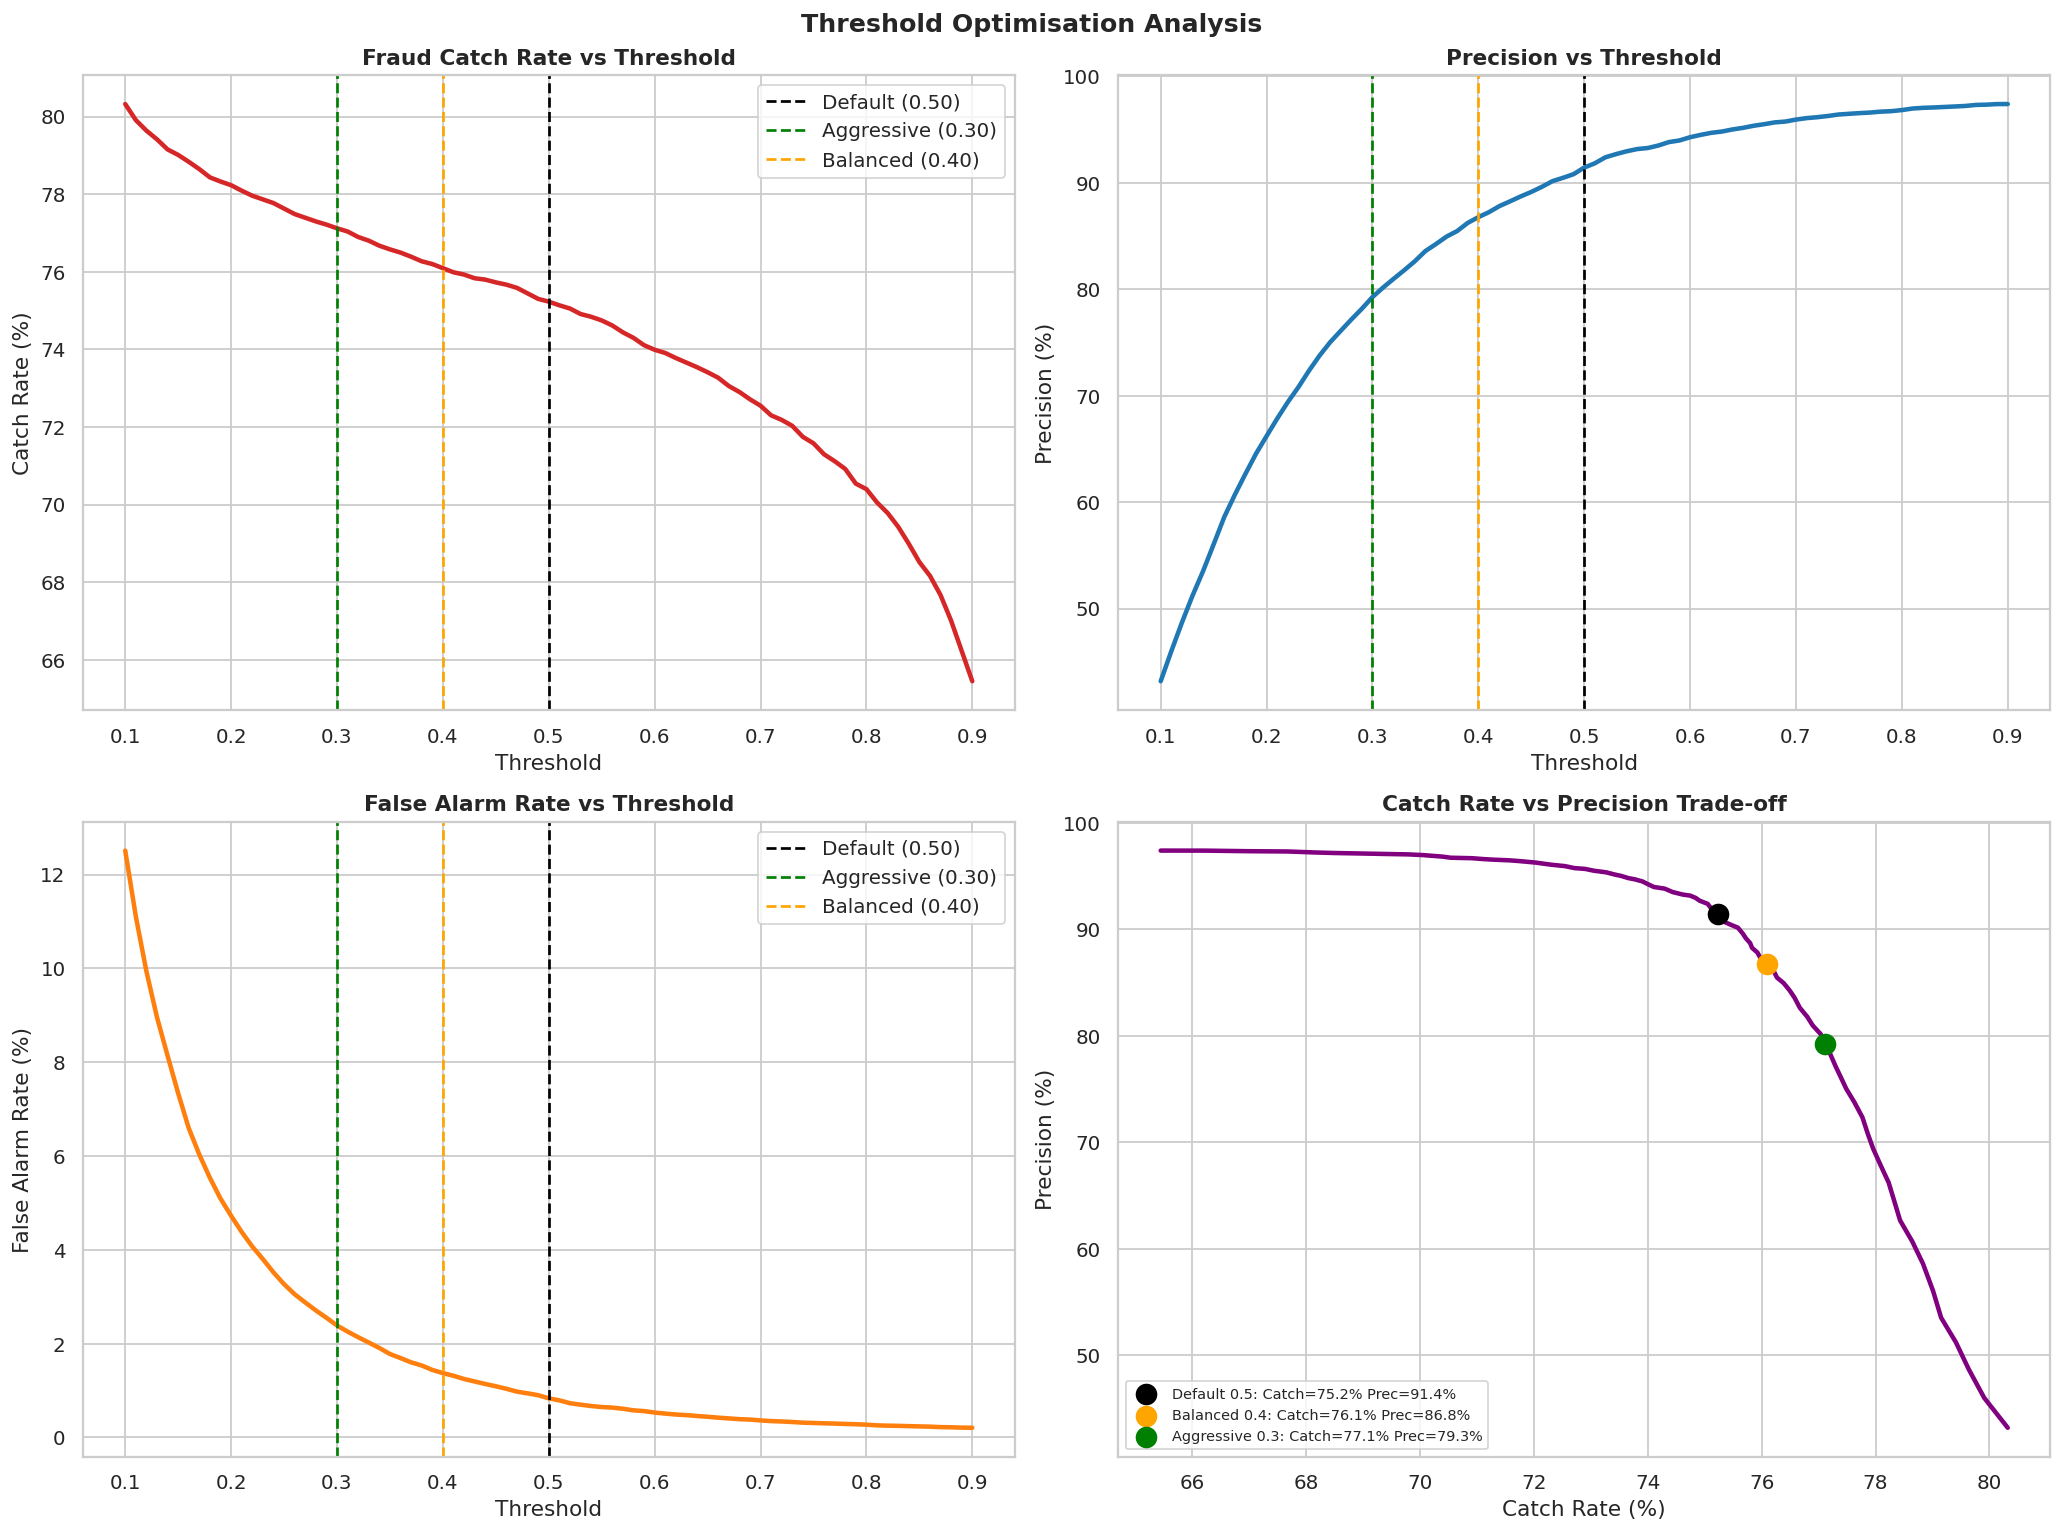


Threshold Comparison Table:
Threshold      Catch Rate    Precision   False Alarms   Fraud Missed
────────────────────────────────────────────────────────────────────
0.50                75.2%        91.4%            597          2,097
0.45                75.7%        89.1%            781          2,055
0.40                76.1%        86.8%            982          2,024
0.35                76.6%        83.6%          1,273          1,983
0.30                77.1%        79.3%          1,708          1,937
0.25                77.6%        73.8%          2,338          1,894
0.20                78.2%        66.2%          3,381          1,843


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

# Get probabilities from tuned model
y_proba = tuned_model.predict_proba(X_test)[:,1]

# Test every threshold from 0.1 to 0.9
thresholds   = np.arange(0.10, 0.91, 0.01)
catch_rates  = []
precision_vals = []
false_alarm_rates = []
f1_scores    = []
fraud_missed_vals = []

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    catch_rates.append(tp / (tp + fn) * 100)
    precision_vals.append(tp / (tp + fp) * 100 if (tp+fp) > 0 else 0)
    false_alarm_rates.append(fp / (fp + tn) * 100)
    f1_scores.append(f1_score(y_test, y_pred_t))
    fraud_missed_vals.append(fn)

# ── Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Catch Rate vs Threshold
axes[0,0].plot(thresholds, catch_rates,
               color='#d62728', linewidth=2.5)
axes[0,0].axvline(0.5, color='black', linestyle='--',
                   linewidth=1.5, label='Default (0.50)')
axes[0,0].axvline(0.3, color='green', linestyle='--',
                   linewidth=1.5, label='Aggressive (0.30)')
axes[0,0].axvline(0.4, color='orange', linestyle='--',
                   linewidth=1.5, label='Balanced (0.40)')
axes[0,0].set_title('Fraud Catch Rate vs Threshold', fontweight='bold')
axes[0,0].set_xlabel('Threshold')
axes[0,0].set_ylabel('Catch Rate (%)')
axes[0,0].legend()

# 2. Precision vs Threshold
axes[0,1].plot(thresholds, precision_vals,
               color='#1f77b4', linewidth=2.5)
axes[0,1].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0,1].axvline(0.3, color='green', linestyle='--', linewidth=1.5)
axes[0,1].axvline(0.4, color='orange', linestyle='--', linewidth=1.5)
axes[0,1].set_title('Precision vs Threshold', fontweight='bold')
axes[0,1].set_xlabel('Threshold')
axes[0,1].set_ylabel('Precision (%)')

# 3. False Alarm Rate vs Threshold
axes[1,0].plot(thresholds, false_alarm_rates,
               color='#ff7f0e', linewidth=2.5)
axes[1,0].axvline(0.5, color='black', linestyle='--',
                   linewidth=1.5, label='Default (0.50)')
axes[1,0].axvline(0.3, color='green', linestyle='--',
                   linewidth=1.5, label='Aggressive (0.30)')
axes[1,0].axvline(0.4, color='orange', linestyle='--',
                   linewidth=1.5, label='Balanced (0.40)')
axes[1,0].set_title('False Alarm Rate vs Threshold', fontweight='bold')
axes[1,0].set_xlabel('Threshold')
axes[1,0].set_ylabel('False Alarm Rate (%)')
axes[1,0].legend()

# 4. Catch Rate vs Precision trade-off
axes[1,1].plot(catch_rates, precision_vals,
               color='purple', linewidth=2.5)

# Mark the three key thresholds
for thresh, color, label in [(0.5,'black','Default 0.5'),
                              (0.4,'orange','Balanced 0.4'),
                              (0.3,'green','Aggressive 0.3')]:
    idx  = np.argmin(np.abs(thresholds - thresh))
    axes[1,1].scatter(catch_rates[idx], precision_vals[idx],
                      color=color, s=120, zorder=5,
                      label=f'{label}: Catch={catch_rates[idx]:.1f}% Prec={precision_vals[idx]:.1f}%')

axes[1,1].set_title('Catch Rate vs Precision Trade-off', fontweight='bold')
axes[1,1].set_xlabel('Catch Rate (%)')
axes[1,1].set_ylabel('Precision (%)')
axes[1,1].legend(fontsize=8)

plt.suptitle('Threshold Optimisation Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print the key comparison table
print("\nThreshold Comparison Table:")
print(f"{'Threshold':<12} {'Catch Rate':>12} {'Precision':>12} "
      f"{'False Alarms':>14} {'Fraud Missed':>14}")
print("─" * 68)

for thresh in [0.5, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    idx  = np.argmin(np.abs(thresholds - thresh))
    y_pred_t      = (y_proba >= thresh).astype(int)
    cm_t          = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    print(f"{thresh:<12.2f} {tp/(tp+fn)*100:>11.1f}% "
          f"{tp/(tp+fp)*100 if tp+fp>0 else 0:>11.1f}% "
          f"{fp:>14,} {fn:>14,}")

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Business Assumption based on EDA
AVG_FRAUD_AMOUNT = 9422

# Calculating False Alarm Cost dynamically
OPS_COST = 500
LTV = 15000
CHURN_RATE = 0.15
FALSE_ALARM_COST = OPS_COST + (CHURN_RATE * LTV)

print(f"Calculated Cost per False Positive (False Alarm): ₹{FALSE_ALARM_COST:,.0f}\n")

financials = []

# Ensure y_test is a numpy array for boolean masking
y_test_array = np.array(y_test)

# Test thresholds from 0.20 to 0.70
for thresh in np.arange(0.20, 0.75, 0.05):
    y_pred_t = (y_proba >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    # 1. The Cost of Friction
    ops_churn_cost = fp * FALSE_ALARM_COST

    # 2. Estimated Savings (The Average Method)
    est_money_saved = tp * AVG_FRAUD_AMOUNT

    # 3. Actual Savings (The Exact Amount Method)
    # Filter X_test to only the rows where actual fraud (1) AND predicted fraud (1) matched
    mask_caught = (y_test_array == 1) & (y_pred_t == 1)
    # Sum the actual raw rupee values from the 'txn_amount' column
    actual_money_saved = X_test.loc[mask_caught, 'txn_amount'].sum()

    # Calculating the ultimate bottom line
    actual_net_profit = actual_money_saved - ops_churn_cost

    # 4. Model Size Bias Check
    if tp > 0:
        avg_caught_size = actual_money_saved / tp
    else:
        avg_caught_size = 0

    financials.append({
        'Threshold': f"{thresh:.2f}",
        'False Alarms': fp,
        'Cost (₹)': ops_churn_cost,
        'Est. Savings (₹)': est_money_saved,
        'Actual Savings (₹)': actual_money_saved,
        'Avg Caught Size (₹)': avg_caught_size,
        'Actual Net Profit (₹)': actual_net_profit
    })

fin_df = pd.DataFrame(financials)

# Formatting for readability
def format_currency(x):
    return f"₹{x:,.0f}"

for col in ['Cost (₹)', 'Est. Savings (₹)', 'Actual Savings (₹)', 'Avg Caught Size (₹)', 'Actual Net Profit (₹)']:
    fin_df[col] = fin_df[col].apply(format_currency)

print("FINANCIAL IMPACT MODEL")
print("-"*115)
print(fin_df.to_string(index=False))

# Finding the best threshold based on ACTUAL profit
best_idx = pd.DataFrame(financials)['Actual Net Profit (₹)'].idxmax()
best_thresh = financials[best_idx]['Threshold']
max_profit = financials[best_idx]['Actual Net Profit (₹)']

print("\n" + "="*115)
print(f"BUSINESS RECOMMENDATION:")
print(f"By tracking exact transaction amounts, the most profitable operating threshold is {best_thresh}.")
print(f"At this threshold, the actual net profit (Money Saved - Cost of False Alarms) is ₹{max_profit:,.0f} on the test set alone.")
print("="*115)

Calculated Cost per False Positive (False Alarm): ₹2,750

FINANCIAL IMPACT MODEL
-------------------------------------------------------------------------------------------------------------------
Threshold  False Alarms   Cost (₹) Est. Savings (₹) Actual Savings (₹) Avg Caught Size (₹) Actual Net Profit (₹)
     0.20          3381 ₹9,297,750      ₹62,401,906        ₹71,077,726             ₹10,732           ₹61,779,976
     0.25          2338 ₹6,429,500      ₹61,921,384        ₹70,637,793             ₹10,748           ₹64,208,293
     0.30          1708 ₹4,697,000      ₹61,516,238        ₹70,405,760             ₹10,784           ₹65,708,760
     0.35          1273 ₹3,500,750      ₹61,082,826        ₹69,602,234             ₹10,736           ₹66,101,484
     0.40           982 ₹2,700,500      ₹60,696,524        ₹69,362,337             ₹10,767           ₹66,661,837
     0.45           781 ₹2,147,750      ₹60,404,442        ₹69,228,479             ₹10,798           ₹67,080,729
     0.50   

In [18]:
exact_total_volume = X_test['txn_amount'].sum()
print(f"Exact Total Test Volume: ₹{exact_total_volume:,.0f}")

Exact Total Test Volume: ₹365,807,240
